# HBN 128-channel EEG preprocessing

Adapts the frozen Menteev N400 pipeline to the **Healthy Brain Network (HBN)** dataset: 128-channel
EGI GSN-HydroCel net (129 labels incl. the Cz reference vertex), online-referenced to Cz, BDF files
downsampled to 100 Hz, with events in BIDS `events.tsv` sidecars. The preprocessing philosophy,
stage order, and QC are unchanged from the reference; only dataset I/O and a few sampling-rate-forced
parameters differ. The frozen output of record is a non-destructive broadband derivative; a
ready-to-use epochs file (contrast-change left/right target) is provided as a convenience.

Run top-to-bottom to process the validation subject through Stages 1–4; call `run_batch()` for all
subjects.

## Limitations & reviewer notes

- **Downsampled release (100 Hz).** The signal is band-limited to a 50 Hz Nyquist: (i) 60 Hz mains
  is out of band, so line-noise removal is skipped; (ii) the ICA-fit copy is 1–45 Hz rather than
  ICLabel's 1–100 Hz range (classification is topography-driven and stays valid); (iii) no
  beta/gamma above 50 Hz for spectral/connectivity work. Full-rate recordings recover all three.
- **Template montage.** `GSN-HydroCel-129` template positions limit source localization to coarse
  fsaverage estimates.
- **Online reference = Cz (flat).** Reconstructed by the average reference (invertible), but carries
  no independent information, so the effective rank is 128.
- **No dedicated EOG/ECG.** Ocular ICs are cross-checked against a frontal (Fp1/Fp2-equivalent)
  blink proxy, not true EOG; cardiac ICs rely on ICLabel alone.
- **ERP product is a convenience derivative.** The left/right-target epochs are a QC-only product
  (labelled as such); the frozen output is the broadband derivative.
- **Pediatric, heterogeneous cohort.** HBN is 5–21 yo with variable data quality; conservative
  adult-scalp defaults are applied identically to every subject.

## References

- Desjardins et al. (2024). *PyLossless: A non-destructive EEG processing pipeline.* bioRxiv.
- Bigdely-Shamlo et al. (2015). *The PREP pipeline.* Front. Neuroinform.
- Kim et al. (2023). Rank deficiency / ghost ICs in EEG ICA.
- de Cheveigné (2020) *ZapLine*; Klug & Kloosterman (2022) *ZapLine-plus*, Hum. Brain Mapp.
- Delorme (2023). *EEG is better left alone.* Sci. Rep.
- Pion-Tonachini et al. (2019). *ICLabel.* NeuroImage; Li et al. (2022) *MNE-ICALabel.*
- Ablin et al. (2018). *Picard.* IEEE TSP.
- Jas et al. (2017). *Autoreject.* NeuroImage.
- Tanner et al. (2015); Acunzo et al. (2012) — high-pass distortion of ERPs.
- Yao (2001) *REST*; Lei & Liao (2017) — reference bias.
- Donoghue et al. (2020). *FOOOF/specparam.* Nat. Neurosci.
- Luck et al. (2021). *Standardized Measurement Error.* Psychophysiology.
- Winkler et al. (2015) — high-pass effect on ICA; Alday (2019) — baseline vs regression.
- Alexander et al. (2017). *HBN.* Sci. Data; Shirazi et al. (2024). *HBN-EEG.* bioRxiv 2024.10.03.615261.


## 1 · Configuration
Every tunable parameter lives here, so a run is fully defined by this section.


In [98]:
# Configuration for the preprocessing pipeline (HBN 128-channel adaptation).
from dataclasses import dataclass, field, asdict
from pathlib import Path
import glob
import os

# DATA PATHS  --  the notebook lives at the dataset root so every path is relative.
DATA_ROOT   = Path(".")             # BIDS dataset root (contains sub-*/eeg/*.bdf)
DERIV_ROOT  = Path("derivatives")   # Output directory for all derived data

# Subjects are discovered from disk for the chosen task/run; events come from the BIDS events.tsv sidecar.
TASK_LABEL  = "contrastChangeDetection"  # primary task for the ready-to-use epochs product
RUN_LABEL   = "run-1"                     # BIDS run entity ("" if the task has no run entity)

def _discover_subjects(task=TASK_LABEL, run=RUN_LABEL):
    """Return {subject_label: {'bdf':path, 'events':path}} for every subject that has"""
    out = {}
    for sub_dir in sorted(glob.glob(str(DATA_ROOT / "sub-*"))):
        sub = os.path.basename(sub_dir).replace("sub-", "")
        stem = f"sub-{sub}_task-{task}" + (f"_{run}" if run else "")
        bdf = DATA_ROOT / f"sub-{sub}" / "eeg" / f"{stem}_eeg.bdf"
        ev  = DATA_ROOT / f"sub-{sub}" / "eeg" / f"{stem}_events.tsv"
        if bdf.exists() and ev.exists():
            out[sub] = {"bdf": str(bdf), "events": str(ev)}
    return out

SUBJECTS = _discover_subjects()
assert SUBJECTS, (f"No subjects found for task='{TASK_LABEL}' run='{RUN_LABEL}' under "
                  f"{DATA_ROOT.resolve()}. Check TASK_LABEL/RUN_LABEL and the dataset path.")
VALIDATION_SUBJECT = next(iter(SUBJECTS))   # first discovered subject drives development/validation

# ACQUISITION FACTS (validated, not assumed -- asserted against the file headers)
EXPECTED_NCHAN    = 129            # [HBN] 128 EGI channels E1..E128 + the Cz reference vertex
MONTAGE_NAME      = "GSN-HydroCel-129"  # [HBN] EGI HydroCel geodesic net (template positions)
REFERENCE_CHANNEL = "Cz"           # online reference vertex: flat until re-referenced, then reconstructed by the average; excluded from bad-channel/rail faults
EXPECTED_CHANNELS = None           # resolved from the montage in the setup cell; channels validated by name, not just count
SFREQ_EXPECTED    = 100.0          # Hz nominal for the L100 release; effective rate validated at ingest
INPUT_UNIT_TO_VOLT = 1.0           # BDF already carries physical units; MNE returns Volts

# Line frequency. HBN was recorded in the USA => 60 Hz mains.
LINE_FREQ         = 60.0           # US mains; above the 50 Hz Nyquist of the 100 Hz release, so the line stage finds no in-band peak and skips

# FILTERING (publication default)  --  filter LATE and LITTLE
# Stored broadband derivative: high-pass only (preserve slow ERP + full spectrum).
HP_FREQ_STORE     = 0.1            # Hz high-pass for the stored data (preserves slow ERP components)
LP_FREQ_STORE     = None           # Hz low-pass for STORED data; None = keep broadband (to Nyquist)
FIR_DESIGN        = "firwin"       # zero-phase FIR; linear phase -> no ERP latency shift

# ICA-fit copy filtering -- must match ICLabel's training distribution as closely as the
# sampling rate allows.
HP_FREQ_ICA       = 1.0            # Hz; ICA needs ~1 Hz HP for stable decomposition (Winkler 2015)
LP_FREQ_ICA       = 45.0           # ICA/ICLabel band ceiling, capped below the 50 Hz Nyquist (ICLabel stays valid on band-limited data)

# ERP analysis-time view (applied when averaging; NOT stored on the broadband file)
LP_FREQ_ERP       = 30.0           # Hz low-pass for ERP display/averaging only (< Nyquist 50)

# BAD-CHANNEL DETECTION (default = PyPREP / RANSAC)
BAD_CH_METHOD     = "pyprep"       # {"pyprep", "robust_mad"}; robust_mad is the lightweight fallback
BAD_CH_MAD_THRESH = 5.0            # robust-SDs on log-variance for the fallback detector
MAX_BAD_FRACTION  = 0.40           # bad-channel guard; higher than a 10-20 cap because the HydroCel peripheral belt is legitimately flagged more often on pediatric data
# Confidence gating. PyPREP's spectral ("psd") criterion over-flags physiologically busy frontal
# channels (blinks/EMG read as odd spectra) on this high-density pediatric net, and interpolating
# them starves ICA of the very sites that carry the blinks. A channel is CONFIRMED bad (excluded
# from the reference + ICA, then interpolated) only if a HARD criterion fired or its variance is
# grossly high; a channel flagged ONLY by a soft criterion at moderate variance is kept, so ICA
# cleans it instead of it being interpolated away.
BAD_CH_SOFT_CRITERIA  = ("psd",)   # single-criterion flags that need corroboration to confirm
BAD_CH_VAR_RATIO_HARD = 30.0       # variance / median-good above this = confirmed bad on its own

# REFERENCE (default = plain AVERAGE reference)  [FROZEN v1.0]
REFERENCE_METHOD  = "average"      # common-average over good channels; reproducible, ICLabel-compatible, invertible

# ICA (publication default)
ICA_METHOD        = "picard"       # Picard converges reliably to the extended-infomax solution
ICA_EXTENDED      = True           # extended-infomax mode -> ICLabel in-distribution (mandatory)
ICA_MAX_ITER      = 2000
ICA_N_COMPONENTS  = None           # None -> set to EFFECTIVE RANK in §10 (prevents "ghost ICs", Kim 2023)
RANK_REL_TOL      = 1e-6           # relative eigenvalue tolerance for effective-rank estimation

# ICLabel automated component rejection thresholds (manual confirmation still required).
ICLABEL_REJECT = {                 # reject an IC if P(class) >= threshold for these artifact classes
    "eye blink":          0.80,
    "muscle artifact":    0.80,
    "heart beat":         0.80,
    "line noise":         0.80,
    "channel noise":      0.80,
}
ICLABEL_BRAIN_KEEP = 0.20          # never auto-reject an IC whose P(brain) exceeds this

# Epoching: lock to the contrast-change visual target and contrast target side (left vs right),
# a lateralised posterior response -- the HBN analogue of the reference's N400 rhyme contrast.
ERP_LOCK_VALUES   = ("left_target", "right_target")  # events.tsv `value`s used as epoch locks
COND_SIDE         = {"left_target": 101, "right_target": 102}  # value -> integer event code
EPOCH_TMIN        = -0.2           # s pre-stimulus
EPOCH_TMAX        = 0.8            # s post-stimulus
BASELINE          = (None, 0.0)    # baseline correction window (regression baseline remains possible)
AUTOREJECT        = True           # data-driven epoch repair/rejection (Jas 2017) at ERP-analysis time

# SPECTRAL / QC
ALPHA_BAND        = (8.0, 13.0)    # Hz posterior alpha (preservation QC)
PSD_FMAX          = 45.0           # [HBN] Hz upper bound for QC PSD plots (< Nyquist 50)
POSTERIOR_FRACTION = 0.5           # posterior-electrode selection as a fraction of most-posterior y

# REPRODUCIBILITY
RANDOM_STATE      = 42             # seeds ICA whitening and any stochastic step

# PERFORMANCE / RESOURCE
N_JOBS            = -1             # parallel jobs for filtering + AutoReject (-1 = all cores); result-invariant
RESAMPLE_SFREQ    = None           # Hz. Optional Nyquist-safe downsample at ingest to speed processing.
#   Refused unless target/2 stays above the analysis band (max(LP_FREQ_ICA, PSD_FMAX)). On this
#   100 Hz release it is OFF -- there is no headroom below the 45 Hz ceiling. On native-rate HBN
#   releases (e.g. 500 Hz) set 250 or 128 for a large speedup with no scientific loss.

print("default configuration loaded.")
print(f"  task={TASK_LABEL} run={RUN_LABEL!r} | subjects discovered={len(SUBJECTS)} "
      f"| validation subject={VALIDATION_SUBJECT}")


default configuration loaded.
  task=contrastChangeDetection run='run-1' | subjects discovered=20 | validation subject=NDARAC904DMU


In [99]:
# EXPERIMENTAL (OPTIONAL) METHOD TOGGLES -> all disabled by default.

# ASR: Artifact Subspace Reconstruction (bursty-artifact pre-ICA cleaning)
USE_ASR            = False
ASR_CUTOFF         = 20.0          # SD cutoff k; lower = more aggressive (Chang 2020 suggest 20-30)
ASR_RATIONALE      = ""            # REQUIRED if USE_ASR: why this recording needs ASR

# Wavelet-enhanced ICA (clean components instead of deleting them; HAPPE/RELAX)
USE_WICA           = False
WICA_WAVELET       = "coif5"
WICA_LEVEL         = 5
WICA_RATIONALE     = ""

# Robust detrending as an alternative to the 0.1 Hz high-pass (de Cheveigne 2018)
USE_ROBUST_DETREND = False
DETREND_ORDER      = 10            # polynomial order for robust detrend
DETREND_RATIONALE  = ""

# PREP robust average reference (alternative to the default plain average)
USE_PREP_REFERENCE = False         # when True, overrides REFERENCE_METHOD with PREP robust average
PREP_REFERENCE_RATIONALE = ""      # REQUIRED if USE_PREP_REFERENCE: why (e.g. bad hardware reference)

# Line-noise removal is EMPIRICAL: only applied if a real mains peak is DETECTED below Nyquist.
# For the 100 Hz HBN release the 60 Hz mains is above the 50 Hz Nyquist, so this never fires;
# the gate is exposed here so the behaviour is explicit (see §6).
APPLY_ZAPLINE_IF_PEAK = True
ZAPLINE_PEAK_DB       = 3.0        # dB above the local 1/f floor to count as a real line peak

EXPERIMENTAL_FLAGS = {
    "USE_ASR": USE_ASR, "USE_WICA": USE_WICA,
    "USE_ROBUST_DETREND": USE_ROBUST_DETREND,
    "USE_PREP_REFERENCE": USE_PREP_REFERENCE,
}
print("Experimental toggles loaded:", EXPERIMENTAL_FLAGS)


Experimental toggles loaded: {'USE_ASR': False, 'USE_WICA': False, 'USE_ROBUST_DETREND': False, 'USE_PREP_REFERENCE': False}


In [100]:
# Quality-control (QC) thresholds.

# Timing and data-integrity QC
QC_SFREQ_DEV_TOL      = 0.02     # max |effective-nominal|/nominal before flagging
QC_MAX_DROP_FRAC      = 0.01     # max net sample-drop fraction before flagging
QC_BURST_PERIOD_FRAC  = 0.5      # dt < this*period counts as an intra-chunk "burst"
QC_CHUNK_BURST_FRAC   = 0.05     # burst fraction above this => chunk-delivered stream
QC_TIMING_HIST_PCT    = 99.0     # upper percentile for the dt-histogram x-range (display)
QC_TIMING_HIST_MIN_MS = 6.0      # minimum dt-histogram x-range (ms, display)

# Initial channel-quality assessment (Raw)
QC_FLAT_VAR_RATIO     = 1e-3     # channel flat if var < this * median(var)
QC_RAILED_RANGE_V     = 1e-9     # channel railed if (max-min) < this (Volts)
QC_BRIDGE_CORR        = 0.99     # channel pair flagged as bridged if corr > this
QC_LOG_EPS            = 1e-30    # epsilon inside log() for variance topography
QC_VARTOPO_PCT        = (5.0, 95.0)   # robust percentile color limits for the variance topomap

# Line-noise detection
QC_LINE_PSD_HALFWIDTH = 15.0     # Hz half-window of the PSD around the line frequency
QC_LINE_PEAK_HW       = 1.0      # Hz half-window taken as the line "peak"
QC_LINE_BASE_LO       = 2.0      # Hz inner edge of the baseline window
QC_LINE_BASE_HI       = 6.0      # Hz outer edge of the baseline window
QC_LINE_NFFT_FACTOR   = 4        # welch n_fft = 2**ceil(log2(sfreq*this)) (~0.25 Hz res)
QC_BANDPOWER_NFFT     = 8192     # welch n_fft for band-power survival checks
QC_BETA_BAND          = (13.0, 30.0)   # Hz beta band for the spectral-survival check
QC_MAINS_CANDIDATES   = (50.0, 60.0)   # mains frequencies to cross-check against LINE_FREQ

# Filtering quality checks
QC_HP_APPLIED_FRAC    = 0.5      # stored highpass must be >= this * HP_FREQ_STORE
QC_SUBHP_FMIN         = 0.02     # Hz lower edge of the sub-edge drift-power probe band
QC_SUBHP_HP_FRAC      = 0.9      # sub-edge probe upper edge = this * HP_FREQ_STORE
QC_SUBHP_NFFT         = 65536    # welch n_fft for the sub-edge drift probe (clamped to recording length in cached_psd)
QC_SUBHP_MAX_RATIO    = 1.10     # high-pass must not amplify sub-edge power (this release is already DC-corrected, so strict attenuation is not required)
QC_HWHP_DC_V          = 1e-8     # per-channel |DC| below this => already hardware high-passed
QC_HF_SANITY_HZ       = 40.0     # [HBN] Hz probe for broadband-preservation sanity (< Nyquist 50)
QC_HF_NYQ_MARGIN      = 5.0      # Hz kept below Nyquist for the HF probe
QC_HF_RATIO_MIN       = 0.5      # min post/pre HF power ratio (broadband preserved)

# ICA and component-quality checks
QC_EOG_PROXY           = None    # frontal blink proxy (Fp1/Fp2-equivalent); derived from montage geometry in the setup cell
QC_ALPHA_MIN_RETAIN    = 0.90    # posterior alpha power must retain >= this fraction after ICA
QC_ICA_MAX_REJECT_FRAC = 0.5     # sanity: auto-reject at most this fraction of components
QC_RANK_TOL            = 1       # allowed |empirical - theoretical| rank mismatch

print("QC_* thresholds loaded.")


QC_* thresholds loaded.


### Processing order
Display order follows Stages 1–4; the internal execution order below is arranged for correctness.

```
ingest BDF + events.tsv  ->  integrity QC (sfreq, sample budget, event bounds)
Step 1  raw overview
line noise               ->  skipped (60 Hz mains > 50 Hz Nyquist)
Step 2  0.1 Hz high-pass (stored)  +  1-45 Hz average-ref copy (for ICA)
bad channels (annotate; Cz reference set aside)  ->  average reference (reconstructs Cz)
effective rank           ->  ICA n_components
Step 3  ICA (Picard extended) -> ICLabel + frontal blink proxy -> confirm -> apply
Step 4  interpolate -> save broadband derivative + ready-to-use epochs
batch over all subjects
```


## 2 · Environment & provenance
Pin package versions and the random seed, and open a per-subject provenance record written to JSON.


In [101]:
# Pipeline initialization and provenance setup.

try:
    get_ipython().run_line_magic("matplotlib", "inline")   # render QC figures inline in the notebook
except Exception:
    pass
import json, platform, time, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

np.random.seed(RANDOM_STATE)
mne.set_log_level("WARNING")

# [HBN] Resolve the exact expected 129-channel NAME set from the montage, so a BDF with the wrong
# or duplicated labels is rejected by name (not merely by count) -- identical guarantee to the
# reference's hard-coded EXPECTED_CHANNELS, but derived from the standard EGI montage.
EXPECTED_CHANNELS = set(mne.channels.make_standard_montage(MONTAGE_NAME).ch_names)
assert len(EXPECTED_CHANNELS) == EXPECTED_NCHAN, (
    f"Montage {MONTAGE_NAME} has {len(EXPECTED_CHANNELS)} channels, expected {EXPECTED_NCHAN}")
assert REFERENCE_CHANNEL in EXPECTED_CHANNELS, (
    f"Reference channel {REFERENCE_CHANNEL} not in montage {MONTAGE_NAME}")

# Frontal blink proxy and posterior visual ROI are DERIVED from montage geometry (not hard-coded
# electrode numbers), so the notebook adapts to any net.
def _montage_xy():
    _p = mne.channels.make_standard_montage(MONTAGE_NAME).get_positions()["ch_pos"]
    return {c: xyz for c, xyz in _p.items() if c != REFERENCE_CHANNEL and xyz is not None}

def _anterior_lr():
    xy = _montage_xy()
    left  = max((c for c in xy if xy[c][0] < 0), key=lambda c: xy[c][1])   # anterior-most left
    right = max((c for c in xy if xy[c][0] > 0), key=lambda c: xy[c][1])   # anterior-most right
    return (left, right)

def _posterior_roi(n=4):
    xy = _montage_xy()
    return tuple(sorted(xy, key=lambda c: xy[c][1])[:n])                   # most posterior n

QC_EOG_PROXY = _anterior_lr()
print(f"derived frontal EOG proxy = {QC_EOG_PROXY} | posterior ROI = {_posterior_roi(4)}")

def _pkg_versions():
    import importlib
    pkgs = ["mne", "numpy", "scipy", "pandas", "matplotlib", "sklearn",
            "mne_icalabel", "autoreject", "pyprep", "picard", "meegkit",
            "specparam", "fooof", "mne_bids"]
    out = {}
    for p in pkgs:
        try:
            out[p] = importlib.import_module(p).__version__
        except Exception:
            out[p] = "not installed"
    return out

PROVENANCE = {
    "pipeline": "hbn_eeg_preprocessing",
    "created": time.strftime("%Y-%m-%dT%H:%M:%S"),
    "python": platform.python_version(),
    "platform": platform.platform(),
    "random_state": RANDOM_STATE,
    "task": TASK_LABEL,
    "run": RUN_LABEL,
    "package_versions": _pkg_versions(),
    "publication_default_config": None,   # filled after config freeze
    "experimental_flags": EXPERIMENTAL_FLAGS,
    "subjects": {},                        # per-subject records appended during processing
}

mne.viz.set_browser_backend("matplotlib")   # static matplotlib figures (render inline, savable to disk)

DERIV_ROOT.mkdir(exist_ok=True)

def _sub_slug(subject):
    return f"sub-{subject}"

def subject_deriv_dir(subject):
    d = DERIV_ROOT / _sub_slug(subject) / "eeg"
    d.mkdir(parents=True, exist_ok=True)
    return d

def figures_dir(subject):
    d = DERIV_ROOT / _sub_slug(subject) / "figures"
    d.mkdir(parents=True, exist_ok=True)
    return d

def save_fig(fig, name, subject):
    """Persist a QC/visualization figure to derivatives/<sub>/figures/<name>.png."""
    path = figures_dir(subject) / f"{name}.png"
    fig.savefig(path, dpi=110, bbox_inches="tight")
    return str(path)   # figure left open so it renders inline; the batch closes them per subject

# Reproducibility identifiers
NOTEBOOK_VERSION = "1.0-hbn"   # this notebook adapts the frozen v1.0 spec to HBN

def _git_commit():
    """Return the current git commit hash, or None if not in a git repo."""
    import subprocess
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"],
            cwd=str(Path(".").resolve()), stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        return None

def config_snapshot():
    """JSON-safe snapshot of the publication-default configuration (sets -> sorted lists)."""
    keys = ["MONTAGE_NAME", "EXPECTED_NCHAN", "EXPECTED_CHANNELS", "REFERENCE_CHANNEL",
            "SFREQ_EXPECTED", "LINE_FREQ", "HP_FREQ_STORE", "LP_FREQ_STORE",
            "HP_FREQ_ICA", "LP_FREQ_ICA", "LP_FREQ_ERP", "FIR_DESIGN",
            "BAD_CH_METHOD", "BAD_CH_MAD_THRESH", "MAX_BAD_FRACTION", "REFERENCE_METHOD",
            "BAD_CH_SOFT_CRITERIA", "BAD_CH_VAR_RATIO_HARD", "N_JOBS", "RESAMPLE_SFREQ",
            "ICA_METHOD", "ICA_EXTENDED", "ICA_MAX_ITER", "RANK_REL_TOL",
            "ICLABEL_REJECT", "ICLABEL_BRAIN_KEEP", "ERP_LOCK_VALUES", "COND_SIDE",
            "EPOCH_TMIN", "EPOCH_TMAX", "BASELINE", "AUTOREJECT", "ALPHA_BAND", "PSD_FMAX",
            "POSTERIOR_FRACTION", "RANDOM_STATE", "TASK_LABEL", "RUN_LABEL",
            # QC_* thresholds (promoted from inline literals)
            "QC_SFREQ_DEV_TOL", "QC_MAX_DROP_FRAC", "QC_BURST_PERIOD_FRAC", "QC_CHUNK_BURST_FRAC",
            "QC_TIMING_HIST_PCT", "QC_TIMING_HIST_MIN_MS", "QC_FLAT_VAR_RATIO", "QC_RAILED_RANGE_V",
            "QC_BRIDGE_CORR", "QC_LOG_EPS", "QC_VARTOPO_PCT", "QC_LINE_PSD_HALFWIDTH",
            "QC_LINE_PEAK_HW", "QC_LINE_BASE_LO", "QC_LINE_BASE_HI", "QC_LINE_NFFT_FACTOR",
            "QC_BANDPOWER_NFFT", "QC_BETA_BAND", "QC_MAINS_CANDIDATES", "QC_HP_APPLIED_FRAC",
            "QC_SUBHP_FMIN", "QC_SUBHP_HP_FRAC", "QC_SUBHP_NFFT", "QC_HWHP_DC_V",
            "QC_HF_SANITY_HZ", "QC_HF_NYQ_MARGIN", "QC_HF_RATIO_MIN",
            "QC_EOG_PROXY", "QC_ALPHA_MIN_RETAIN", "QC_ICA_MAX_REJECT_FRAC", "QC_RANK_TOL"]
    snap = {}
    for k in keys:
        if k in globals():
            v = globals()[k]
            snap[k] = sorted(v) if isinstance(v, (set, frozenset)) else v
    return snap

_cfg = config_snapshot()
_cfg_json = json.dumps(_cfg, sort_keys=True, default=str)

PROVENANCE["notebook_version"] = NOTEBOOK_VERSION
PROVENANCE["git_commit"] = _git_commit()
PROVENANCE["processing_timestamp"] = time.strftime("%Y-%m-%dT%H:%M:%S")
PROVENANCE["publication_default_config"] = _cfg
PROVENANCE["config_hash"] = hashlib.sha256(_cfg_json.encode()).hexdigest()[:16]

def init_subject_provenance(subject):
    """Create/refresh a per-subject provenance record with identity + timestamp."""
    rec = PROVENANCE["subjects"].setdefault(subject, {})
    rec["subject_id"] = subject
    rec["processing_timestamp"] = time.strftime("%Y-%m-%dT%H:%M:%S")
    rec["config_hash"] = PROVENANCE["config_hash"]
    return rec

def write_provenance(subject):
    """Persist the full provenance record to derivatives/<sub>/provenance.json (JSON-safe)."""
    path = subject_deriv_dir(subject) / "provenance.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(PROVENANCE, f, indent=2, default=str)
    return str(path)

print(f"Provenance initialized | notebook v{NOTEBOOK_VERSION} | "
      f"git {PROVENANCE['git_commit'] or 'N/A'} | config {PROVENANCE['config_hash']}")
print(json.dumps(PROVENANCE["package_versions"], indent=2))


derived frontal EOG proxy = ('E21', 'E14') | posterior ROI = ('E75', 'E70', 'E83', 'E74')
Provenance initialized | notebook v1.0-hbn | git N/A | config 172fa033503290cb
{
  "mne": "1.12.1",
  "numpy": "2.4.3",
  "scipy": "1.17.1",
  "pandas": "2.2.3",
  "matplotlib": "3.10.9",
  "sklearn": "1.6.1",
  "mne_icalabel": "0.9.0",
  "autoreject": "0.4.4",
  "pyprep": "0.7.1",
  "picard": "0.8.2",
  "meegkit": "0.1.9",
  "specparam": "2.0.0rc7",
  "fooof": "1.1.1",
  "mne_bids": "0.19.0"
}


In [102]:
# Shared analysis helpers (defined once, used by every stage).
from scipy.integrate import simpson

def get_posterior_channels(raw):
    """Posterior electrodes (y < POSTERIOR_FRACTION * most-posterior y), excluding bads."""
    pos = raw.get_montage().get_positions()["ch_pos"]
    ys = {ch: pos[ch][1] for ch in raw.ch_names
          if ch in pos and ch not in raw.info["bads"]}
    min_y = min(ys.values())
    thr = POSTERIOR_FRACTION * min_y
    return [ch for ch, y in ys.items() if y < thr]

_PSD_CACHE = {}
def cached_psd(raw, method="welch", fmin=0.0, fmax=None, n_fft=None, picks=None):
    """Return (freqs, data) for a PSD, memoized on the raw object identity + parameters."""
    if n_fft is not None:
        n_fft = int(min(n_fft, raw.n_times))
    key = (id(raw), getattr(raw, "_last_time", None), method,
           round(float(fmin), 4), None if fmax is None else round(float(fmax), 4),
           n_fft, tuple(picks) if picks is not None else None, raw.n_times)
    if key not in _PSD_CACHE:
        kw = dict(method=method, fmin=fmin, verbose=False)
        if fmax is not None: kw["fmax"] = fmax
        if n_fft is not None: kw["n_fft"] = n_fft
        if picks is not None: kw["picks"] = picks
        p = raw.compute_psd(**kw)
        _PSD_CACHE[key] = (p.freqs.copy(), p.get_data().copy())
    f, d = _PSD_CACHE[key]
    return f.copy(), d.copy()

def _bandpower(raw, lo, hi, picks=None):
    """Integrated Welch band-power (V^2) via Simpson integration -- the single definition of"""
    f, d = cached_psd(raw, method="welch", fmin=lo, fmax=hi,
                      n_fft=QC_BANDPOWER_NFFT, picks=picks)
    return float(simpson(d.mean(axis=0), x=f))

def nyquist(raw):
    return raw.info["sfreq"] / 2.0

def maybe_resample(raw):
    """Optional Nyquist-safe downsample (RESAMPLE_SFREQ) applied once at ingest for speed. Refuses
    to go below 2x the analysis band, and never upsamples; a no-op when RESAMPLE_SFREQ is None or
    not below the source rate (as on the 100 Hz release)."""
    if RESAMPLE_SFREQ is None:
        return raw
    src = float(raw.info["sfreq"])
    band = max(LP_FREQ_ICA, PSD_FMAX)
    if RESAMPLE_SFREQ >= src:
        print(f"  resample skipped: target {RESAMPLE_SFREQ} Hz not below source {src:.0f} Hz.")
        return raw
    if RESAMPLE_SFREQ <= 2.0 * band:
        print(f"  resample skipped: target {RESAMPLE_SFREQ} Hz would violate Nyquist for the "
              f"{band:.0f} Hz analysis band.")
        return raw
    raw.resample(RESAMPLE_SFREQ, npad="auto", n_jobs=N_JOBS, verbose=False)
    print(f"  resampled {src:.0f} -> {RESAMPLE_SFREQ:.0f} Hz ({band:.0f} Hz analysis band preserved).")
    return raw

print("analysis helpers loaded (get_posterior_channels, cached_psd, _bandpower, nyquist).")


analysis helpers loaded (get_posterior_channels, cached_psd, _bandpower, nyquist).


## 3 · Optional methods (off by default)
ASR / wICA / robust-detrend / PREP-reference are available but disabled; enabling one requires a written rationale and logs a before/after comparison.


In [103]:
# Utility functions for experimental preprocessing stages.
def _optional_stage_comparison(name, raw_in, raw_out, subject):
    """Standardized before/after comparison (PSD overlay, per-channel variance, effective rank,"""
    nyq = nyquist(raw_in)
    fmax = min(PSD_FMAX, nyq - 1)
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))

    # (1) PSD overlay (mean across channels)
    f0, d0 = cached_psd(raw_in, fmax=fmax)
    f1, d1 = cached_psd(raw_out, fmax=fmax)
    ax[0, 0].plot(f0, 10 * np.log10(d0.mean(0)), "k", lw=1, label="before")
    ax[0, 0].plot(f1, 10 * np.log10(d1.mean(0)), "r", lw=1, label="after")
    ax[0, 0].set(title="PSD overlay", xlabel="Frequency (Hz)", ylabel="Power (dB)")
    ax[0, 0].legend()

    # (2) per-channel variance comparison
    v0 = np.var(raw_in.get_data(), axis=1) * 1e12
    v1 = np.var(raw_out.get_data(), axis=1) * 1e12
    lim = [0, float(max(v0.max(), v1.max()))]
    ax[0, 1].scatter(v0, v1, s=12)
    ax[0, 1].plot(lim, lim, "k--", lw=0.8)
    ax[0, 1].set(title="per-channel variance (uV^2)", xlabel="before", ylabel="after")

    # (3) effective rank comparison (same estimator as the rank stage)
    def _rank(r):
        picks = mne.pick_types(r.info, eeg=True, exclude="bads")
        e = np.linalg.eigvalsh(np.cov(r.get_data(picks=picks))); e = e[e > 0]
        return int(np.sum(e > e.max() * RANK_REL_TOL))
    r0, r1 = _rank(raw_in), _rank(raw_out)
    ax[1, 0].bar(["before", "after"], [r0, r1], color=["k", "r"])
    ax[1, 0].set(title=f"effective rank ({r0} -> {r1})", ylabel="rank")

    # (4) posterior alpha power comparison (integrated band power)
    post = get_posterior_channels(raw_in)
    a0 = _bandpower(raw_in, ALPHA_BAND[0], ALPHA_BAND[1], picks=post)
    a1 = _bandpower(raw_out, ALPHA_BAND[0], ALPHA_BAND[1], picks=post)
    ax[1, 1].bar(["before", "after"], [a0, a1], color=["k", "r"])
    ax[1, 1].set(title=f"posterior alpha power ({100 * a1 / a0:.1f}% retained)",
                 ylabel="integrated power")

    fig.suptitle(f'[{subject}] optional stage "{name}" - before/after comparison')
    save_fig(fig, f"optional_{name}_comparison", subject)


def optional_stage(name, enabled, rationale, params, fn, raw_in, metric_fn, subject):
    # 1. disabled -> no-op, do not execute fn, no provenance record.
    if not enabled:
        return raw_in
    # 2. enabled but no rationale -> refuse to run anonymously.
    if not rationale or not rationale.strip():
        raise ValueError(f"Experimental stage '{name}' requires a non-empty rationale.")
    # 3-7. snapshot, time, execute, snapshot.
    before = metric_fn(raw_in)
    _t0 = time.perf_counter()
    raw_out = fn(raw_in.copy())
    runtime_s = time.perf_counter() - _t0
    after = metric_fn(raw_out)
    # 8. standardized before/after comparison via existing plotting utility.
    _optional_stage_comparison(name, raw_in, raw_out, subject)
    # 9. append the provenance record (create the list if absent).
    rec = PROVENANCE["subjects"].setdefault(subject, {})
    rec.setdefault("optional_stages", []).append({
        "name": name, "enabled": enabled, "rationale": rationale, "params": params,
        "before": before, "after": after, "runtime_s": runtime_s,
    })
    # 10. return the processed data.
    return raw_out


## 4 · Stage 1 — Ingest & integrity
Read the BDF, attach the GSN-HydroCel-129 montage, and load events from the BIDS `events.tsv`. Validate channels by name, the sampling rate, and that every event falls inside the recording.


In [104]:
# load_hbn_recording: robust BDF ingest for one subject/task/run.
def load_hbn_recording(subject, task=TASK_LABEL, run=RUN_LABEL):
    rec = SUBJECTS[subject]
    bdf_path, ev_path = Path(rec["bdf"]), Path(rec["events"])

    # ---- file-integrity checks (new validation) --------------------------------------------
    for p in (bdf_path, ev_path):
        if not p.exists():
            raise FileNotFoundError(f"Missing input for {subject}: {p}")
        if p.stat().st_size == 0:
            raise ValueError(f"Empty input file for {subject}: {p}")

    raw = mne.io.read_raw_bdf(str(bdf_path), preload=True, verbose=False)

    # ---- channel + sampling validation (by NAME, not just count) ----------------------------
    ch_names = list(raw.ch_names)
    assert len(ch_names) == EXPECTED_NCHAN, (
        f"[{subject}] expected {EXPECTED_NCHAN} channels, got {len(ch_names)}")
    assert len(set(ch_names)) == len(ch_names), (
        f"[{subject}] duplicate channel labels: "
        f"{[c for c in ch_names if ch_names.count(c) > 1]}")
    got = set(ch_names)
    if got != EXPECTED_CHANNELS:
        raise AssertionError(
            "[{}] channel-name set mismatch vs {} montage. missing={} unexpected={}".format(
                subject, MONTAGE_NAME,
                sorted(EXPECTED_CHANNELS - got), sorted(got - EXPECTED_CHANNELS)))
    sf = float(raw.info["sfreq"])
    assert abs(sf - SFREQ_EXPECTED) / SFREQ_EXPECTED < QC_SFREQ_DEV_TOL, (
        f"[{subject}] sampling frequency {sf} Hz deviates from expected {SFREQ_EXPECTED} Hz")

    # unit safeguard: BDF should already be in Volts (INPUT_UNIT_TO_VOLT == 1.0); apply only if a
    # non-identity conversion was configured (kept for parity with the reference contract).
    if INPUT_UNIT_TO_VOLT != 1.0:
        raw.apply_function(lambda x: x * INPUT_UNIT_TO_VOLT, verbose=False)

    # on_missing='raise' -> a montage/name mismatch fails loudly instead of silently leaving
    # channels position-less (which would corrupt topography/ICLabel/interpolation).
    raw.set_montage(mne.channels.make_standard_montage(MONTAGE_NAME),
                    on_missing="raise", verbose=False)

    raw = maybe_resample(raw)          # optional Nyquist-safe downsample for speed (no-op at 100 Hz)
    sf = float(raw.info["sfreq"])      # refresh after any resample

    # ---- events from the BIDS sidecar -> annotations + events -------------------------------
    df = pd.read_csv(ev_path, sep="\t")
    onsets = pd.to_numeric(df["onset"], errors="coerce").to_numpy(dtype=float)
    labels = df["value"].astype(str).to_numpy()
    duration_s = raw.n_times / sf
    in_bounds = np.isfinite(onsets) & (onsets >= 0) & (onsets <= duration_s)
    ann = mne.Annotations(onset=onsets[in_bounds],
                          duration=np.zeros(int(in_bounds.sum())),
                          description=labels[in_bounds])
    raw.set_annotations(ann)
    events, event_id = mne.events_from_annotations(raw, verbose=False)

    marker_df = pd.DataFrame({"onset_s": onsets, "label": labels, "in_bounds": in_bounds})
    n_dropped = int((~in_bounds).sum())
    if n_dropped:
        print(f"NOTE: {n_dropped} event(s) fell outside the EEG time span and were dropped.")

    # regular BDF sample times feed the (trivially uniform) integrity QC below.
    eeg_ts = raw.times.copy()
    return raw, events, event_id, marker_df, eeg_ts


In [105]:
# integrity_qc: sampling/sample-budget integrity for a regularly sampled BDF recording.
def integrity_qc(eeg_timestamps, nominal_sfreq, subject):
    ts = np.asarray(eeg_timestamps, dtype=float)
    n = ts.size
    span = ts[-1] - ts[0]
    eff = (n - 1) / span if span > 0 else nominal_sfreq
    period = 1.0 / nominal_sfreq
    dt = np.diff(ts)
    dt_ms = dt * 1000.0
    med = float(np.median(dt)) if dt.size else period
    jitter_ms = float(np.std(dt) * 1000.0) if dt.size else 0.0

    # (a) authoritative loss measure
    expected = int(round(span * nominal_sfreq)) + 1   # inclusive sample count for a regular grid
    net_drop = expected - n
    drop_frac = abs(net_drop) / expected

    # transport pattern (trivially uniform for BDF; kept for output parity)
    burst_frac = float(np.mean(dt < QC_BURST_PERIOD_FRAC * period)) if dt.size else 0.0
    chunked = burst_frac > QC_CHUNK_BURST_FRAC
    monotonic = bool(np.all(dt >= 0)) if dt.size else True

    # (c) genuine stalls (none expected on a regular grid)
    stall_thresh_ms = 1000.0 * (period * 3.0)   # >3x nominal period = a real gap
    stall_mask = dt_ms > stall_thresh_ms
    n_stalls = int(stall_mask.sum())
    max_gap_ms = float(dt_ms.max()) if dt.size else 0.0
    max_gap_time_s = float(ts[:-1][np.argmax(dt)] - ts[0]) if dt.size else 0.0

    metrics = dict(
        n_samples=int(n), span_s=float(span),
        effective_sfreq=float(eff), nominal_sfreq=float(nominal_sfreq),
        expected_samples=int(expected), net_sample_drop=int(net_drop),
        net_drop_frac=float(drop_frac), median_dt_ms=med * 1000.0, jitter_ms=jitter_ms,
        transport="chunked" if chunked else "uniform", burst_fraction=burst_frac,
        monotonic=monotonic, stall_threshold_ms=float(stall_thresh_ms),
        n_stalls=n_stalls, max_gap_ms=max_gap_ms, max_gap_time_s=max_gap_time_s,
    )

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(dt_ms, lw=0.4)
    ax[0].axhline(period * 1000.0, color="g", lw=1, label="nominal period")
    ax[0].axhline(stall_thresh_ms, color="r", ls="--", lw=1, label=f"stall threshold ({stall_thresh_ms:.0f} ms)")
    ax[0].set(title="Inter-sample interval over time", xlabel="sample index", ylabel="dt (ms)")
    ax[0].legend(loc="upper right", fontsize=8)
    hi = max(QC_TIMING_HIST_MIN_MS, float(np.percentile(dt_ms, QC_TIMING_HIST_PCT))) if dt.size else QC_TIMING_HIST_MIN_MS
    ax[1].hist(dt_ms, bins=120, range=(0, hi))
    ax[1].axvline(period * 1000.0, color="g", lw=1)
    ax[1].set(title="dt distribution (bulk, <=99th pct)", xlabel="dt (ms)", ylabel="count")
    fig.suptitle(f"[{subject}] Data-integrity / timing QC  (transport: {metrics['transport']})")
    save_fig(fig, "step0_timing_qc", subject)

    dev = abs(eff - nominal_sfreq) / nominal_sfreq
    ok = (dev < QC_SFREQ_DEV_TOL) and (drop_frac < QC_MAX_DROP_FRAC) and monotonic

    print(f"[{subject}] samples={n} (expected {expected}; net drop {net_drop} = {drop_frac*100:.3f}%)  "
          f"span={span:.1f}s  effective={eff:.2f} Hz (dev {dev*100:.3f}%)  monotonic={monotonic}")
    print(f"           transport={metrics['transport']} (burst frac {burst_frac*100:.1f}%), "
          f"median dt={med*1000:.3f} ms, jitter={jitter_ms:.3f} ms  -- regular BDF sampling")
    print(f"           genuine stalls (>{stall_thresh_ms:.0f} ms)={n_stalls}  "
          f"largest={max_gap_ms:.1f} ms @ t={max_gap_time_s:.1f}s")
    if not ok:
        print("  ** WARNING: net sample budget / effective rate / monotonicity out of tolerance.")
    else:
        print("  PASS: regular sampling, net sample budget intact, no stalls.")
    return metrics, ok


[NDARAC904DMU] samples=23500 (expected 23500; net drop 0 = 0.000%)  span=235.0s  effective=100.00 Hz (dev 0.000%)  monotonic=True
           transport=uniform (burst frac 0.0%), median dt=10.000 ms, jitter=0.000 ms  -- regular BDF sampling
           genuine stalls (>30 ms)=0  largest=10.0 ms @ t=128.0s
  PASS: regular sampling, net sample budget intact, no stalls.

Detected event_id (first 15): {np.str_('9999'): 1, np.str_('break cnt'): 2, np.str_('contrastChangeB1_start'): 3, np.str_('contrastTrial_start'): 4, np.str_('left_buttonPress'): 5, np.str_('left_target'): 6, np.str_('right_buttonPress'): 7, np.str_('right_target'): 8}


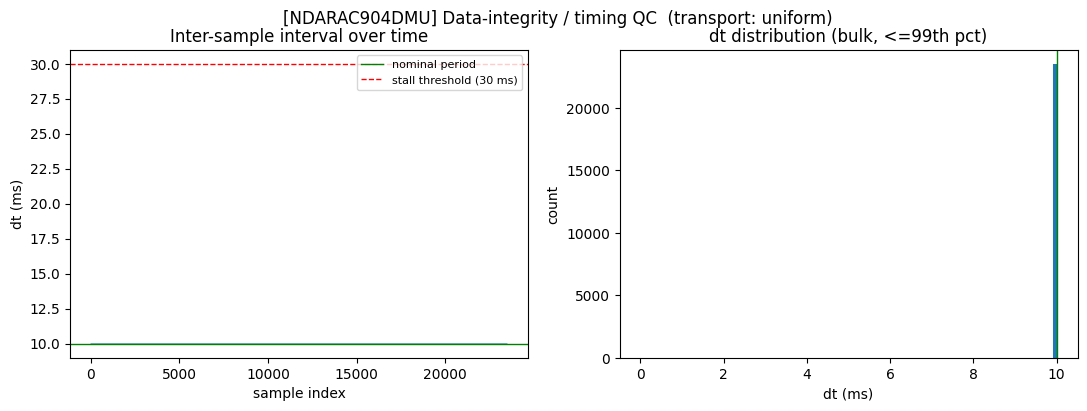

In [106]:
# section 4 DRIVER  -  ingest + data-integrity QC on the validation subject
# (real execution; every assertion below must pass)

raw, events, event_id, marker_df, eeg_ts = load_hbn_recording(VALIDATION_SUBJECT)
timing, timing_ok = integrity_qc(eeg_ts, raw.info["sfreq"], VALIDATION_SUBJECT)

assert len(raw.ch_names) == EXPECTED_NCHAN
assert raw.get_montage() is not None
assert timing_ok, (f"Timing out of tolerance: effective {timing['effective_sfreq']:.2f} Hz, "
                   f"net sample drop {timing['net_sample_drop']}")

init_subject_provenance(VALIDATION_SUBJECT)
PROVENANCE["subjects"][VALIDATION_SUBJECT]["timing"] = timing
print("\nDetected event_id (first 15):",
      dict(list(sorted(event_id.items()))[:15]))


## 5 · Characterisation
Summarise the recording and confirm the left/right target lock-events are present and populated (the HBN analogue of the reference's trigger↔behaviour cross-check).


In [107]:
# characterize + event cross-check (HBN events.tsv).
def characterize(raw, events, event_id, marker_df, subject):
    from collections import Counter
    sfreq = raw.info["sfreq"]
    dur = raw.n_times / sfreq

    ch = list(raw.ch_names)
    dups = [c for c, k in Counter(ch).items() if k > 1]
    assert not dups, f"Duplicate channels: {dups}"
    montage_ok = raw.get_montage() is not None

    inv = dict(Counter(marker_df.loc[marker_df["in_bounds"], "label"]))

    # lock-event inventory (the HBN equivalent of the CSV trigger cross-check)
    n_lock = {v: int(inv.get(v, 0)) for v in ERP_LOCK_VALUES}
    n_lock_total = int(sum(n_lock.values()))
    both_conditions = all(n_lock[v] > 0 for v in ERP_LOCK_VALUES)
    events_ok = (n_lock_total > 0) and both_conditions

    info = dict(
        subject=subject,
        n_channels=len(ch),
        sfreq=float(sfreq),
        duration_s=float(dur),
        montage_attached=bool(montage_ok),
        n_markers_in_bounds=int(marker_df["in_bounds"].sum()),
        marker_inventory=inv,
        lock_event_counts=n_lock,
        n_lock_events=n_lock_total,
        both_conditions_present=bool(both_conditions),
        events_ok=bool(events_ok),
    )

    print(f"[{subject}] channels={len(ch)}  sfreq={sfreq:.1f} Hz  duration={dur:.1f}s  "
          f"montage={'ok' if montage_ok else 'MISSING'}")
    print(f"           markers in-bounds={info['n_markers_in_bounds']}")
    print(f"           lock events {dict(n_lock)} (total {n_lock_total})  both conditions={both_conditions}")
    if not events_ok:
        print("  ** WARNING: lock events missing or a condition is empty -> epoching will be blocked "
              "for this subject (continuous QC still produced).")
    return info, events_ok


### Step 1 — Raw overview
Inspect the untouched EEG (traces, PSD, montage, per-channel variance/kurtosis, flat/railed/bridged checks). The Cz vertex reads flat here because it is the online reference.


In [108]:
montage = raw.get_montage()
pos = montage.get_positions()
print("Coordinate frame:", pos["coord_frame"])
# print the frontal EOG-proxy and reference vertex positions as a montage sanity check
for _ch in list(QC_EOG_PROXY) + [REFERENCE_CHANNEL]:
    if _ch in pos["ch_pos"]:
        print(f"{_ch}:", np.round(pos['ch_pos'][_ch], 4))


Coordinate frame: head
E21: [-0.0138  0.1041  0.0148]
E14: [0.0138 0.1041 0.0148]
Cz: [0.     0.0125 0.131 ]


In [109]:
# STEP 1 - completely raw EEG overview + first-look QC.
def step1_raw_overview(raw, events, event_id, subject):
    from scipy.stats import kurtosis
    sfreq = raw.info["sfreq"]
    nyq = nyquist(raw)
    # exclude the flat online-reference vertex from all first-look stats/spectra/topography: its
    # variance, kurtosis and PSD are undefined before re-referencing (they warn and distort maps).
    picks_noref = [i for i, c in enumerate(raw.ch_names) if c != REFERENCE_CHANNEL]
    names_nr = [raw.ch_names[i] for i in picks_noref]

    # (1) continuous traces from a mid-recording window (avoids start-up transients)
    start = float(raw.n_times / sfreq * 0.3)
    f1 = raw.plot(duration=20.0, start=start, n_channels=min(30, len(raw.ch_names)),
                  scalings=dict(eeg=50e-6), show=False, title=f"[{subject}] STEP 1 raw traces")
    save_fig(f1, "step1_raw_traces", subject)

    # (2) raw PSD (QC band); no mains peak is observable at 100 Hz
    fq, dq = cached_psd(raw, fmax=min(PSD_FMAX, nyq - 1), picks=picks_noref)
    f2, ax2 = plt.subplots(figsize=(9, 4))
    ax2.plot(fq, 10 * np.log10(dq.mean(0)), lw=1)
    ax2.set(title=f"[{subject}] STEP 1 raw PSD", xlabel="Frequency (Hz)", ylabel="Power (dB)")
    save_fig(f2, "step1_raw_psd", subject)

    # (2b) full-band PSD to Nyquist -- documents the absence of any line peak/harmonic below 50 Hz.
    fw, dw = cached_psd(raw, fmax=nyq, picks=picks_noref)
    f2b, axw = plt.subplots(figsize=(9, 4))
    axw.plot(fw, 10 * np.log10(dw.mean(0)), lw=1)
    axw.set(title=f"[{subject}] STEP 1 raw PSD (full band, to Nyquist {nyq:.0f} Hz)",
            xlabel="Frequency (Hz)", ylabel="Power (dB)")
    for h in np.arange(LINE_FREQ, nyq, LINE_FREQ):   # empty when LINE_FREQ > Nyquist (HBN case)
        axw.axvline(h, color="r", ls=":", lw=0.8)
    save_fig(f2b, "step1_raw_psd_wide", subject)

    # (3) sensor layout (montage sanity) -- 129 sensors, names hidden for legibility
    f3 = raw.plot_sensors(show_names=False, show=False)
    save_fig(f3, "step1_sensors", subject)

    # (4) event/marker alignment
    f4 = mne.viz.plot_events(events, sfreq=sfreq, event_id=event_id, show=False)
    f4.suptitle(f"[{subject}] STEP 1 events")
    save_fig(f4, "step1_events", subject)

    # (5) per-channel statistics (reference vertex excluded)
    data = raw.get_data(picks=picks_noref)
    var = np.var(data, axis=1)
    kurt = kurtosis(data, axis=1)
    stats = pd.DataFrame({"channel": names_nr,
                          "var_uV2": var * 1e12,
                          "kurtosis": kurt}).sort_values("var_uV2", ascending=False)

    # (7) flatline / rail detection (reference vertex handled separately -- flat by design)
    flat = [names_nr[i] for i in np.where(var < np.median(var) * QC_FLAT_VAR_RATIO)[0]]
    rng = data.max(axis=1) - data.min(axis=1)
    railed = [names_nr[i] for i in np.where(rng < QC_RAILED_RANGE_V)[0]]
    _refvar = float(np.var(raw.get_data(picks=[REFERENCE_CHANNEL])[0])) if REFERENCE_CHANNEL in raw.ch_names else 0.0
    ref_flat = bool(_refvar < np.median(var) * QC_FLAT_VAR_RATIO)

    # (6) log-variance topography (ref excluded) with robust percentile colour limits
    f5, ax5 = plt.subplots(figsize=(4.5, 4))
    logvar = np.log(var + QC_LOG_EPS)
    _vlim = (float(np.percentile(logvar, QC_VARTOPO_PCT[0])),
             float(np.percentile(logvar, QC_VARTOPO_PCT[1])))
    mne.viz.plot_topomap(logvar, mne.pick_info(raw.info, picks_noref), axes=ax5, show=False, vlim=_vlim)
    ax5.set_title(f"[{subject}] log-variance topography")
    save_fig(f5, "step1_var_topo", subject)

    # (8) electrode-bridging: near-unity correlation between channels (vectorized, ref excluded)
    C = np.corrcoef(data)
    iu = np.triu_indices_from(C, k=1)
    bridged = [(names_nr[i], names_nr[j], float(C[i, j]))
               for i, j in zip(*iu) if C[i, j] > QC_BRIDGE_CORR]

    print(f"[{subject}] STEP 1 QC")
    print(f"  variance range: {stats['var_uV2'].min():.2f} - {stats['var_uV2'].max():.2f} uV^2")
    print(f"  highest-variance channels:\n{stats.head(5).to_string(index=False)}")
    print(f"  reference vertex {REFERENCE_CHANNEL} flat (expected, online reference): {ref_flat}")
    print(f"  flat channels (excl. reference): {flat if flat else 'none'}")
    print(f"  railed channels (excl. reference): {railed if railed else 'none'}")
    print(f"  bridged pairs (r>{QC_BRIDGE_CORR}): {len(bridged)} pair(s)")
    stats.to_csv(subject_deriv_dir(subject) / "step1_channel_statistics.csv", index=False)
    return dict(stats=stats, flat_channels=flat, railed_channels=railed,
                bridged_pairs=bridged, reference_flat=bool(ref_flat))


[NDARAC904DMU] channels=129  sfreq=100.0 Hz  duration=235.0s  montage=ok
           markers in-bounds=80
           lock events {'left_target': 12, 'right_target': 12} (total 24)  both conditions=True
[NDARAC904DMU] STEP 1 QC
  variance range: 337.65 - 492746.13 uV^2
  highest-variance channels:
channel       var_uV2   kurtosis
   E128 492746.132194 179.694572
    E33 137977.813459 185.485397
    E32 136117.140110  95.753894
    E52  73297.640796 179.286800
    E48  50976.426249  58.248965
  reference vertex Cz flat (expected, online reference): True
  flat channels (excl. reference): none
  railed channels (excl. reference): none
  bridged pairs (r>0.99): 5 pair(s)

STAGE 1 COMPLETE: ingest + integrity QC + STEP 1 raw visualization.


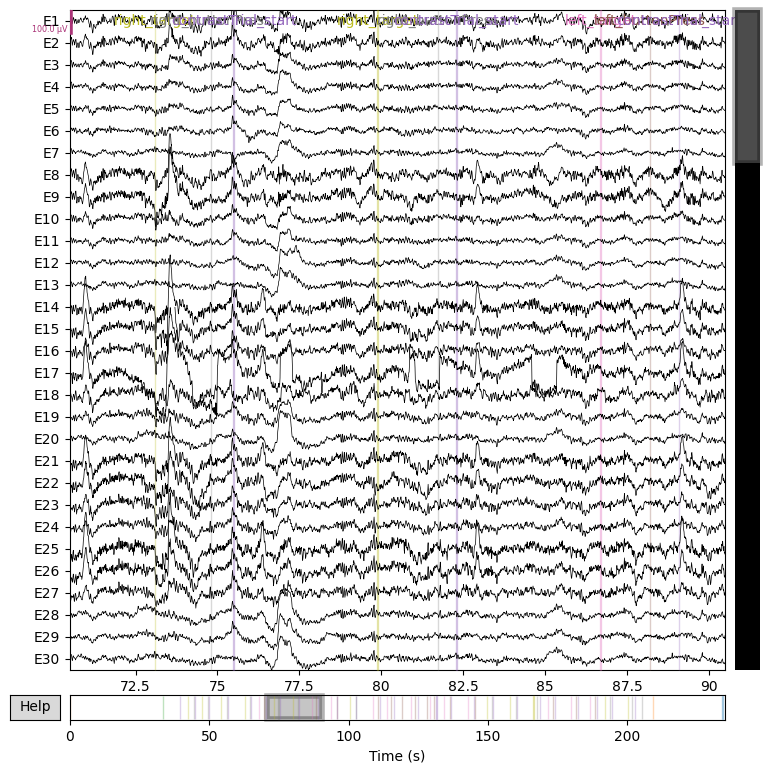

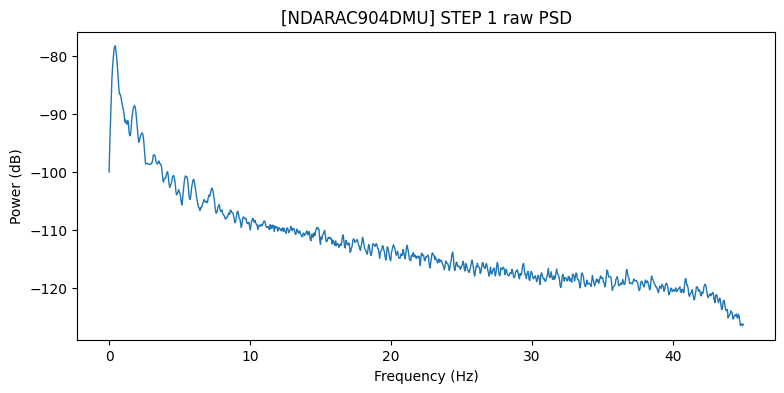

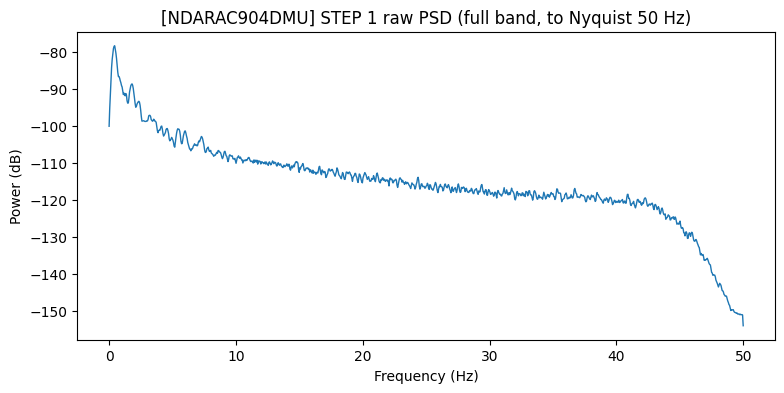

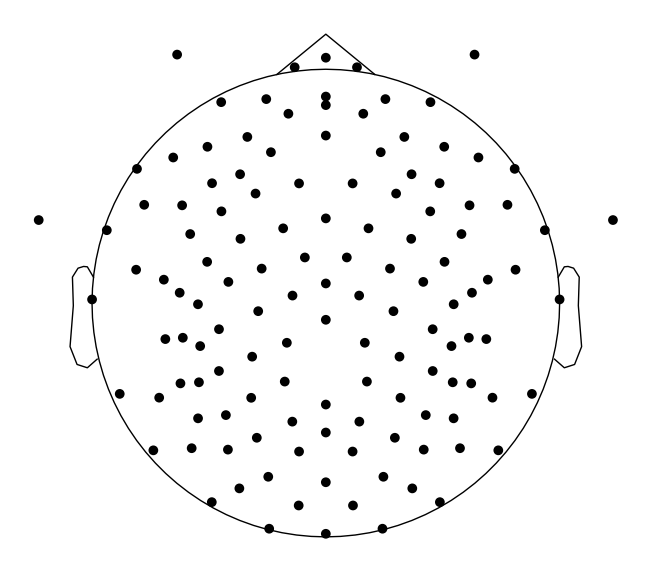

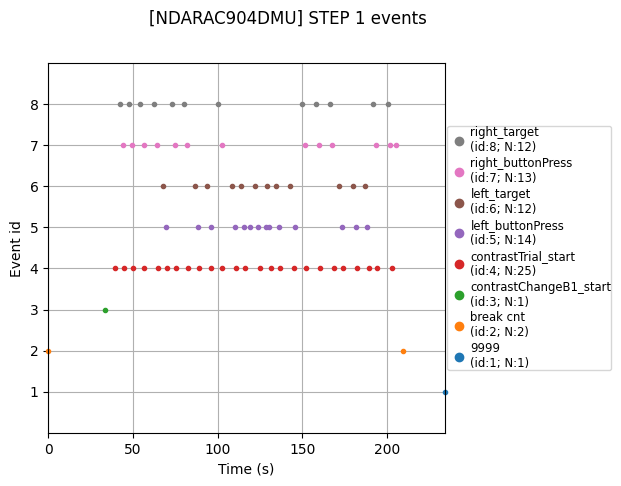

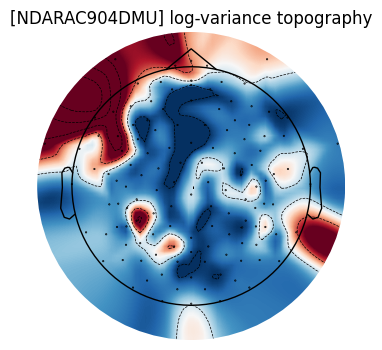

In [110]:
# section 5 / STEP 1 DRIVER  -  characterize + raw visualization (pre-preprocessing)

charac, events_ok = characterize(raw, events, event_id, marker_df, VALIDATION_SUBJECT)
step1 = step1_raw_overview(raw, events, event_id, VALIDATION_SUBJECT)

# STEP 1 must succeed before ANY preprocessing is applied. The online-reference vertex is flat by
# design and is excluded from the rail fault list, so a genuine railed channel still fails here.
assert not step1["railed_channels"], f"Railed channels present: {step1['railed_channels']}"
# validation output check: the reference vertex should indeed read flat before re-referencing.
assert step1["reference_flat"], (
    f"Expected the online reference {REFERENCE_CHANNEL} to be flat before re-referencing.")

PROVENANCE["subjects"][VALIDATION_SUBJECT]["characterization"] = charac
PROVENANCE["subjects"][VALIDATION_SUBJECT]["step1_flat"] = step1["flat_channels"]
PROVENANCE["subjects"][VALIDATION_SUBJECT]["step1_bridged"] = step1["bridged_pairs"]
print("\nSTAGE 1 COMPLETE: ingest + integrity QC + STEP 1 raw visualization.")


## 6 · Line noise
ZapLine-plus is applied only if a real mains peak is detected. At 100 Hz the 60 Hz mains is above the 50 Hz Nyquist, so the stage reports *not observable* and skips.


In [111]:
# Line-noise assessment (empirical) and optional ZapLine-plus removal.
def detect_line_peak(raw, line_freq=None):
    line_freq = float(LINE_FREQ if line_freq is None else line_freq)
    sf = raw.info["sfreq"]
    nyq = sf / 2.0
    # [HBN] out-of-band guard: a mains peak at/above Nyquist cannot be observed or removed.
    if line_freq >= nyq - QC_LINE_PEAK_HW:
        return dict(line_freq=line_freq, observable=False,
                    prominence_db_median=float("nan"), prominence_db_max=float("nan"),
                    threshold_db=float(ZAPLINE_PEAK_DB), has_peak=False,
                    reason=f"line freq {line_freq:.0f} Hz >= Nyquist {nyq:.0f} Hz (out of band)")
    n_fft = int(2 ** np.ceil(np.log2(sf * QC_LINE_NFFT_FACTOR)))  # ~0.25 Hz resolution
    fmax = min(nyq - 1.0, line_freq + QC_LINE_PSD_HALFWIDTH)
    freqs, P = cached_psd(raw, method="welch", fmin=max(1.0, line_freq - QC_LINE_PSD_HALFWIDTH),
                          fmax=fmax, n_fft=n_fft)
    peak_mask = np.abs(freqs - line_freq) <= QC_LINE_PEAK_HW
    base_mask = (np.abs(freqs - line_freq) >= QC_LINE_BASE_LO) & (np.abs(freqs - line_freq) <= QC_LINE_BASE_HI)
    peak = P[:, peak_mask].max(axis=1)
    base = np.median(P[:, base_mask], axis=1)
    prom_db = 10.0 * np.log10(peak / base)
    return dict(line_freq=line_freq, observable=True,
                prominence_db_median=float(np.median(prom_db)),
                prominence_db_max=float(np.max(prom_db)),
                threshold_db=float(ZAPLINE_PEAK_DB),
                has_peak=bool(np.median(prom_db) > ZAPLINE_PEAK_DB))

def apply_zapline(raw):
    import contextlib, io
    import meegkit
    sf = raw.info["sfreq"]
    X = raw.get_data().T                                 # (n_times, n_chans), Volts
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        clean, n_iter = meegkit.dss.dss_line_iter(X, float(LINE_FREQ), sf, nfft=512)
    raw_out = raw.copy()
    raw_out._data[:] = clean.T
    return raw_out, int(n_iter)

def run_line_noise(raw, subject):
    m = detect_line_peak(raw)
    if not m.get("observable", True):
        print(f"[{subject}] line-noise @ {m['line_freq']:.0f} Hz: NOT OBSERVABLE -> {m['reason']}. "
              f"ZapLine skipped (no in-band mains peak on the {raw.info['sfreq']:.0f} Hz release).")
        raw_out = raw.copy()
        info = dict(m, zapline_applied=False, zapline_iterations=0, runtime_s=0.0,
                    offline_peak_warnings=[])
        return raw_out, info

    print(f"[{subject}] line-noise @ {m['line_freq']:.0f} Hz: prominence "
          f"median={m['prominence_db_median']:.2f} dB, max={m['prominence_db_max']:.2f} dB "
          f"(threshold {m['threshold_db']:.1f} dB) -> peak={'YES' if m['has_peak'] else 'no'}")

    import time as _time
    applied, n_iter, runtime_s = False, 0, 0.0
    if APPLY_ZAPLINE_IF_PEAK and m["has_peak"]:
        _t0 = _time.perf_counter()
        raw_out, n_iter = apply_zapline(raw)
        runtime_s = _time.perf_counter() - _t0
        applied = True
        print(f"           ZapLine-plus applied ({n_iter} iteration(s), components auto-selected, "
              f"{runtime_s:.1f}s).")
    else:
        raw_out = raw.copy()
        print("           No genuine line peak (or gate off) -> ZapLine skipped.")

    # before/after PSD zoom around the line frequency
    fig, ax = plt.subplots(figsize=(7.5, 4))
    sf = raw.info["sfreq"]
    n_fft = int(2 ** np.ceil(np.log2(sf * QC_LINE_NFFT_FACTOR)))
    for lbl, r, col in [("before", raw, "k"), ("after", raw_out, "r")]:
        f, d = cached_psd(r, method="welch", fmin=m["line_freq"] - QC_LINE_PSD_HALFWIDTH,
                          fmax=min(sf / 2 - 1, m["line_freq"] + QC_LINE_PSD_HALFWIDTH), n_fft=n_fft)
        ax.plot(f, 10 * np.log10(d.mean(0)), color=col, lw=1.2, label=lbl)
    ax.axvline(m["line_freq"], color="b", ls=":", lw=0.8)
    ax.set(title=f"[{subject}] STEP 2 line-noise @ {m['line_freq']:.0f} Hz (before/after)",
           xlabel="Frequency (Hz)", ylabel="Power (dB)")
    ax.legend()
    save_fig(fig, "step2_line_noise", subject)

    info = dict(m, zapline_applied=applied, zapline_iterations=int(n_iter),
                runtime_s=float(runtime_s))
    if applied:
        after = detect_line_peak(raw_out)
        info["prominence_db_after"] = after["prominence_db_median"]
        info["attenuation_db"] = float(m["prominence_db_median"] - after["prominence_db_median"])
        def _rank(r):
            e = np.linalg.eigvalsh(np.cov(r.get_data())); e = e[e > 0]
            return int((e > e.max() * RANK_REL_TOL).sum())
        info["rank_before"] = _rank(raw); info["rank_after"] = _rank(raw_out)
        info["effective_rank_change"] = info["rank_before"] - info["rank_after"]
        for nm, lo, hi in [("alpha", ALPHA_BAND[0], ALPHA_BAND[1]),
                           ("beta", QC_BETA_BAND[0], QC_BETA_BAND[1]),
                           ("broadband", 1.0, PSD_FMAX)]:
            info[f"{nm}_survival"] = _bandpower(raw_out, lo, hi) / _bandpower(raw, lo, hi)
    # Generalization guard: warn if a strong peak sits at another IN-BAND mains candidate.
    info["offline_peak_warnings"] = []
    nyq = raw.info["sfreq"] / 2.0
    for f_alt in QC_MAINS_CANDIDATES:
        if abs(f_alt - float(LINE_FREQ)) < 0.5 or f_alt >= nyq - QC_LINE_PEAK_HW:
            continue
        alt = detect_line_peak(raw, line_freq=f_alt)
        if alt.get("observable", False) and alt["prominence_db_median"] > ZAPLINE_PEAK_DB:
            w = (f"strong {f_alt:.0f} Hz peak ({alt['prominence_db_median']:.1f} dB) present "
                 f"but LINE_FREQ={float(LINE_FREQ):.0f} Hz -- verify the mains frequency")
            info["offline_peak_warnings"].append(w); print("  ** WARNING:", w)
    return raw_out, info


In [112]:
# section 6 DRIVER  -  line-noise assessment (+ optional ZapLine) on the raw recording
# Runs on the UNPROCESSED raw from Stage 1; produces `raw_line` (a copy when nothing is applied).

raw_line, line_info = run_line_noise(raw, VALIDATION_SUBJECT)

# Dynamic QC (direction-only, no dataset-specific magnitude thresholds):
if line_info["zapline_applied"]:
    assert line_info["prominence_db_after"] < line_info["prominence_db_median"], \
        "ZapLine did not reduce the line-peak prominence."
# annotations/events must survive the line-noise stage unchanged
assert len(raw_line.annotations) == len(raw.annotations)
events_after, event_id_after = mne.events_from_annotations(raw_line, verbose=False)
assert np.array_equal(events_after, events)
assert event_id_after == event_id

PROVENANCE["subjects"][VALIDATION_SUBJECT]["line_noise"] = line_info
print("line-noise stage OK:", {k: line_info.get(k) for k in
      ("observable", "has_peak", "zapline_applied", "zapline_iterations")})


[NDARAC904DMU] line-noise @ 60 Hz: NOT OBSERVABLE -> line freq 60 Hz >= Nyquist 50 Hz (out of band). ZapLine skipped (no in-band mains peak on the 100 Hz release).
line-noise stage OK: {'observable': False, 'has_peak': False, 'zapline_applied': False, 'zapline_iterations': 0}


## 7 · Stage 2 — Filtering
Store a 0.1 Hz high-passed broadband copy (slow ERP + full spectrum preserved) and a separate 1–45 Hz average-referenced copy for ICA. Zero-phase FIR, so no ERP latency shift.


In [113]:
# STEP 2 - filtering: stored broadband view (0.1 Hz HP) + ICA-fit view (1-45 Hz).
def apply_filters(raw):
    if USE_ROBUST_DETREND:
        raise NotImplementedError(
            "USE_ROBUST_DETREND is enabled but the robust-detrend experimental stage is not "
            "implemented yet. Disable it to use the publication-default 0.1 Hz high-pass.")
    nyq = nyquist(raw)
    lp_ica = min(LP_FREQ_ICA, nyq - QC_HF_NYQ_MARGIN)   # [HBN] safeguard: keep ICA LP below Nyquist
    raw_store = raw.copy().filter(
        l_freq=HP_FREQ_STORE, h_freq=LP_FREQ_STORE,
        method="fir", fir_design=FIR_DESIGN, phase="zero", n_jobs=N_JOBS, verbose=False)
    raw_ica_fit = raw.copy().filter(
        l_freq=HP_FREQ_ICA, h_freq=lp_ica,
        method="fir", fir_design=FIR_DESIGN, phase="zero", n_jobs=N_JOBS, verbose=False)
    metrics = dict(hp_store=HP_FREQ_STORE, lp_store=LP_FREQ_STORE,
                   hp_ica=HP_FREQ_ICA, lp_ica=float(lp_ica), lp_ica_config=LP_FREQ_ICA,
                   store_highpass=float(raw_store.info["highpass"]),
                   store_lowpass=float(raw_store.info["lowpass"]))
    return raw_store, raw_ica_fit, metrics

def step2_visualize(raw_pre, raw_store, raw_ica_fit, subject):
    sf = raw_store.info["sfreq"]
    nyq = sf / 2.0
    lp_ica = raw_ica_fit.info["lowpass"]

    # (1) filter frequency responses (magnitude/phase) for both filtered views
    h_store = mne.filter.create_filter(None, sf, HP_FREQ_STORE, LP_FREQ_STORE,
                                        method="fir", fir_design=FIR_DESIGN, phase="zero", verbose=False)
    f1 = mne.viz.plot_filter(h_store, sf, show=False)
    f1.suptitle(f"[{subject}] STEP 2 stored-data filter (HP {HP_FREQ_STORE} Hz, zero-phase)")
    save_fig(f1, "step2_filter_response_store", subject)

    h_ica = mne.filter.create_filter(None, sf, HP_FREQ_ICA, lp_ica,
                                      method="fir", fir_design=FIR_DESIGN, phase="zero", verbose=False)
    f2 = mne.viz.plot_filter(h_ica, sf, show=False)
    f2.suptitle(f"[{subject}] STEP 2 ICA-fit filter ({HP_FREQ_ICA}-{lp_ica:.0f} Hz)")
    save_fig(f2, "step2_filter_response_ica", subject)

    # (2) PSD before vs after the stored high-pass (full band, log-x)
    fpre, dpre = cached_psd(raw_pre, fmax=nyq)
    fpost, dpost = cached_psd(raw_store, fmax=nyq)
    f3, ax = plt.subplots(figsize=(9, 4))
    ax.plot(fpre, 10 * np.log10(dpre.mean(0)), "k", lw=1, label="before filter")
    ax.plot(fpost, 10 * np.log10(dpost.mean(0)), "r", lw=1,
            label=f"after {HP_FREQ_STORE} Hz HP (stored, broadband)")
    ax.axvline(HP_FREQ_STORE, color="b", ls=":", lw=0.8)
    ax.set(xscale="log", xlabel="Frequency (Hz)", ylabel="Power (dB)",
           title=f"[{subject}] STEP 2 PSD before/after filtering")
    ax.legend()
    save_fig(f3, "step2_psd_before_after", subject)

    # (3) drift removal on a representative frontal channel (E22 ~ Fp1; fallback first channel)
    ch = QC_EOG_PROXY[0] if QC_EOG_PROXY[0] in raw_pre.ch_names else raw_pre.ch_names[0]
    idx = raw_pre.ch_names.index(ch)
    a = int(sf * min(300.0, raw_pre.n_times / sf * 0.25))
    b = a + int(sf * 30.0)
    t = np.arange(b - a) / sf
    f4, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    ax[0].plot(t, raw_pre.get_data()[idx, a:b] * 1e6, "k", lw=0.6)
    ax[0].set(title=f"[{subject}] {ch} before filter (drift/offset visible)", ylabel="uV")
    ax[1].plot(t, raw_store.get_data()[idx, a:b] * 1e6, "r", lw=0.6)
    ax[1].set(title=f"{ch} after {HP_FREQ_STORE} Hz high-pass", xlabel="Time (s)", ylabel="uV")
    save_fig(f4, "step2_traces_before_after", subject)

    # power-preservation summary at a high frequency (broadband sanity, direction-only)
    def _power_at(freqs, d, fhz):
        j = int(np.argmin(np.abs(freqs - fhz)))
        return float(d.mean(0)[j])
    fhi = min(QC_HF_SANITY_HZ, nyq - QC_HF_NYQ_MARGIN)
    return dict(hf_ratio=_power_at(fpost, dpost, fhi) / _power_at(fpre, dpre, fhi), hf_freq=fhi)


C:\Users\Shreesh\AppData\Local\Temp\ipykernel_16500\1159493270.py:26: UserWarning: Zero value in spectrum for channel Cz
  p = raw.compute_psd(**kw)


filtering OK | store HP=0.10 Hz LP=50.0 Hz | ICA-fit LP=45 Hz | alpha retained=1.000 | sub-0.1Hz power ratio=1.006 | HF power ratio@40Hz=1.00
  NOTE: sub-edge power ~unchanged (ratio 1.006) -> the recording is already effectively high-passed/DC-corrected upstream; the 0.1 Hz HP has little drift to remove.
Provenance written: derivatives\sub-NDARAC904DMU\eeg\provenance.json | warnings: 2

STAGE 2 COMPLETE: line-noise assessment + STEP 2 filtering.


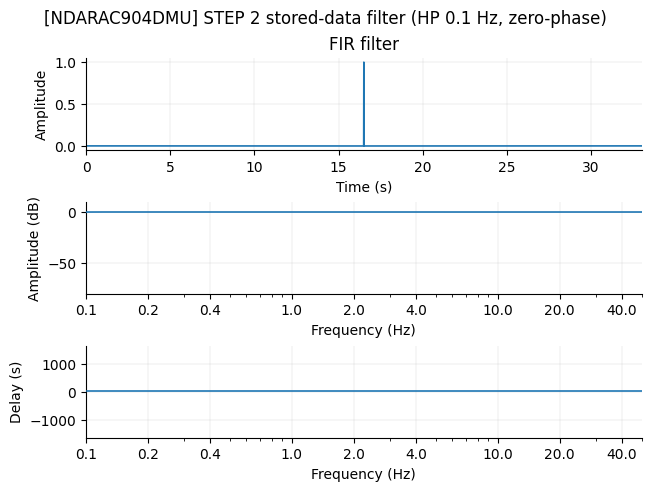

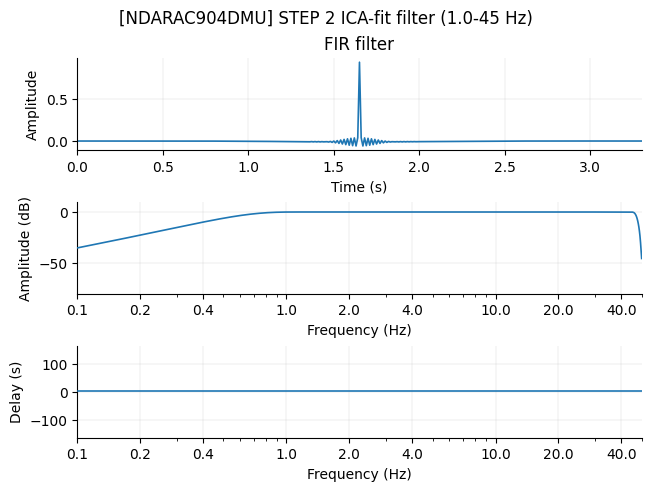

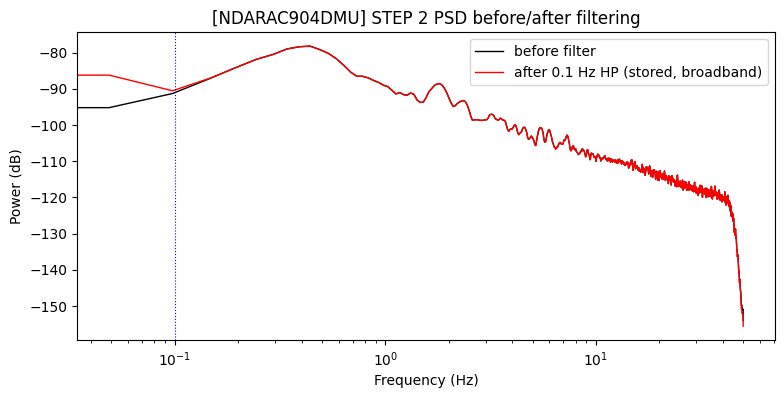

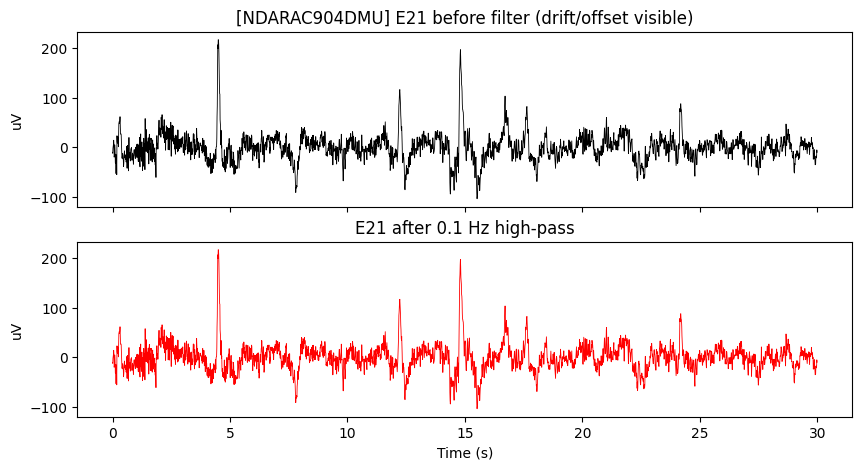

In [114]:
# section 7 / STEP 2 DRIVER  -  filtering + visualization
raw_store, raw_ica_fit, filt_metrics = apply_filters(raw_line)
step2 = step2_visualize(raw_line, raw_store, raw_ica_fit, VALIDATION_SUBJECT)
posterior = get_posterior_channels(raw_store)

# Posterior alpha preservation after filtering (should keep physiological alpha, remove drift).
alpha_pre = _bandpower(raw_line, ALPHA_BAND[0], ALPHA_BAND[1], picks=posterior)
alpha_post = _bandpower(raw_store, ALPHA_BAND[0], ALPHA_BAND[1], picks=posterior)
alpha_retention = alpha_post / alpha_pre

# Dynamic QC:
# (a) high-pass actually recorded on the stored data
assert raw_store.info["highpass"] >= HP_FREQ_STORE * QC_HP_APPLIED_FRAC, "Stored high-pass not applied."
# (b) high-pass ACTS on drift: sub-edge (0.02..0.9*HP Hz) power is attenuated.
def _subhp_power(r):
    f, d = cached_psd(r, method="welch", fmin=QC_SUBHP_FMIN,
                      fmax=HP_FREQ_STORE * QC_SUBHP_HP_FRAC, n_fft=QC_SUBHP_NFFT)
    return float(d.mean())
sub_pre = _subhp_power(raw_line)
sub_post = _subhp_power(raw_store)
subhp_ratio = sub_post / sub_pre
# The 0.1 Hz high-pass must ATTENUATE the sub-edge drift band (or, on already-high-passed data,
# leave it unchanged) -- it must NEVER amplify it. [HBN] This release is already effectively
# DC-corrected (negligible <0.1 Hz drift), so the reference's strict post<pre would fail on
# estimation noise; we assert the filter does not increase sub-edge power beyond QC_SUBHP_MAX_RATIO
# and report whether genuine drift was removed.
assert subhp_ratio <= QC_SUBHP_MAX_RATIO, (
    f"High-pass amplified sub-edge (drift) power (ratio {subhp_ratio:.3f} > {QC_SUBHP_MAX_RATIO}).")
already_highpassed = subhp_ratio > 0.9   # little/no attenuation => data already high-passed upstream
dc_pre = float(np.mean(np.abs(raw_line.get_data().mean(axis=1))))
dc_post = float(np.mean(np.abs(raw_store.get_data().mean(axis=1))))
hw_hp_note = (dc_pre < QC_HWHP_DC_V) or already_highpassed  # near-zero DC / no drift => pre-high-passed
# (c) broadband preserved (no stored low-pass): high-freq power ~unchanged (generic sanity)
assert step2["hf_ratio"] > QC_HF_RATIO_MIN, f"High-frequency power unexpectedly attenuated ({step2['hf_ratio']:.2f})."
# (d) annotations and derived events survive filtering unchanged
assert len(raw_store.annotations) == len(raw_line.annotations)
events_after, event_id_after = mne.events_from_annotations(raw_store, verbose=False)
assert np.array_equal(events_after, events), "Filtering altered event timing."
assert event_id_after == event_id, "Filtering altered event labels."

PROVENANCE["subjects"][VALIDATION_SUBJECT]["filtering"] = dict(
    filt_metrics, hf_ratio=step2["hf_ratio"], subhp_power_ratio=sub_post / sub_pre,
    dc_pre=dc_pre, dc_post=dc_post, hardware_highpassed=bool(hw_hp_note),
    already_highpassed=bool(already_highpassed), alpha_retention=alpha_retention)
print(f"filtering OK | store HP={raw_store.info['highpass']:.2f} Hz "
      f"LP={raw_store.info['lowpass']:.1f} Hz | ICA-fit LP={raw_ica_fit.info['lowpass']:.0f} Hz "
      f"| alpha retained={alpha_retention:.3f} | sub-{HP_FREQ_STORE}Hz power ratio={subhp_ratio:.3f} "
      f"| HF power ratio@{step2['hf_freq']:.0f}Hz={step2['hf_ratio']:.2f}")
if already_highpassed:
    print(f"  NOTE: sub-edge power ~unchanged (ratio {subhp_ratio:.3f}) -> the recording is already "
          f"effectively high-passed/DC-corrected upstream; the 0.1 Hz HP has little drift to remove.")

# Consolidate QC + warnings into provenance and persist provenance.json (audit requirement).
_subj = PROVENANCE["subjects"][VALIDATION_SUBJECT]
_t = _subj["timing"]
_warn = []
if _t["n_stalls"] > 0:
    _warn.append(f"{_t['n_stalls']} timing stall(s) > {_t['stall_threshold_ms']:.0f} ms")
if not _subj["line_noise"].get("observable", True):
    _warn.append(f"line noise not assessable: {_subj['line_noise'].get('reason','')}")
if _subj.get("step1_bridged"):
    _warn.append(f"candidate bridged channel pair(s): {len(_subj['step1_bridged'])}")
if not _subj["characterization"]["events_ok"]:
    _warn.append("lock events missing or a condition empty")
_warn += _subj["line_noise"].get("offline_peak_warnings", [])
_subj["warnings"] = _warn
_subj["qc_results"] = {
    "timing_ok": bool(timing_ok),
    "events_ok": bool(_subj["characterization"]["events_ok"]),
    "line_observable": bool(_subj["line_noise"].get("observable", False)),
    "zapline_applied": bool(_subj["line_noise"]["zapline_applied"]),
    "sub_hp_power_ratio": _subj["filtering"]["subhp_power_ratio"],
    "hf_power_ratio": _subj["filtering"]["hf_ratio"],
    "alpha_retention": alpha_retention,
}
_prov_path = write_provenance(VALIDATION_SUBJECT)
print("Provenance written:", _prov_path, "| warnings:", len(_warn))
print("\nSTAGE 2 COMPLETE: line-noise assessment + STEP 2 filtering.")


## 8 · Bad channels (annotate, don't delete)
PyPREP flags noisy channels before referencing; they are marked, not removed. The flat Cz reference is set aside so it is never mistaken for a bad channel.


In [115]:
# Bad-channel detection (PyPREP default) -- annotate, do NOT interpolate here.
def detect_bad_channels(raw):
    method = BAD_CH_METHOD
    reasons = {}
    # [HBN] exclude the flat reference vertex from detection entirely.
    det = raw.copy()
    if REFERENCE_CHANNEL in det.ch_names:
        det.drop_channels([REFERENCE_CHANNEL])

    if method == "pyprep":
        from pyprep.find_noisy_channels import NoisyChannels
        nc = NoisyChannels(det, random_state=RANDOM_STATE)
        nc.find_all_bads()
        try:
            d = nc.get_bads(as_dict=True)
            for cat, chs in d.items():
                if cat == "bad_all":
                    continue
                for ch in (chs or []):
                    reasons.setdefault(ch, []).append(cat.replace("bad_by_", ""))
            bads = sorted(d.get("bad_all", nc.get_bads()))
        except TypeError:
            bads = sorted(nc.get_bads())
    elif method == "robust_mad":
        data = det.get_data(picks=mne.pick_types(det.info, eeg=True))
        logv = np.log(np.var(data, axis=1) + QC_LOG_EPS)
        med = np.median(logv); mad = np.median(np.abs(logv - med))
        rsd = 1.4826 * mad if mad > 0 else np.std(logv)
        z = (logv - med) / rsd
        names = [det.ch_names[i] for i in mne.pick_types(det.info, eeg=True)]
        bads = [names[i] for i in np.where(np.abs(z) > BAD_CH_MAD_THRESH)[0]]
        for b in bads:
            reasons[b] = ["robust_mad_logvar"]
    else:
        raise ValueError(f"Unknown BAD_CH_METHOD: {method}")

    # safety: the reference vertex must never appear in bads (it was excluded from detection).
    bads = [b for b in bads if b != REFERENCE_CHANNEL]

    # CONFIDENCE GATING: confirm a channel bad only if a HARD criterion fired or its variance is
    # grossly high; demote soft-only (e.g. "psd") moderate-variance channels back to good so ICA
    # can clean their blinks/EMG instead of them being interpolated away.
    _vs = np.var(raw.get_data(), axis=1)
    _med_good = float(np.median(_vs)) + QC_LOG_EPS
    _var_ratio = {c: float(_vs[raw.ch_names.index(c)] / _med_good) for c in bads}
    confirmed, demoted = [], []
    for b in bads:
        hard = [c for c in reasons.get(b, []) if c not in BAD_CH_SOFT_CRITERIA]
        if hard or _var_ratio[b] > BAD_CH_VAR_RATIO_HARD:
            confirmed.append(b)
        else:
            demoted.append(b)
    bads = sorted(confirmed)
    frac = len(bads) / len(raw.ch_names)
    raw.info["bads"] = list(bads)     # ANNOTATE (interpolation deferred to STEP 4)
    raw.info["temp"] = raw.info.get("temp", {}) or {}
    raw.info["temp"]["bad_channel_reasons"] = {b: reasons.get(b, []) for b in bads}
    raw.info["temp"]["demoted_soft_only"] = sorted(demoted)
    print(f"[bad-channel] method={method}  confirmed bads={len(bads)}/{len(raw.ch_names)} "
          f"({frac*100:.1f}%) -> {bads if bads else 'none'}  (reference {REFERENCE_CHANNEL} excluded)")
    if demoted:
        print(f"             demoted {len(demoted)} soft-only ({'/'.join(BAD_CH_SOFT_CRITERIA)}) "
              f"channel(s) kept for ICA: {sorted(demoted)}")
    for ch in bads:
        print(f"             {ch}: {', '.join(reasons.get(ch, []))} (var {_var_ratio[ch]:.1f}x median)")
    if frac > MAX_BAD_FRACTION:
        print(f"  ** WARNING: bad fraction {frac*100:.1f}% exceeds MAX_BAD_FRACTION "
              f"{MAX_BAD_FRACTION*100:.0f}%.")
    return bads, reasons, frac


## 9 · Average reference
Re-reference to the common average over good channels — reproducible, ICLabel-compatible, invertible — which also reconstructs the flat Cz vertex.


In [116]:
# Reference (publication default = plain AVERAGE) + auto-generated comparison doc.
def apply_reference(raw):
    if USE_PREP_REFERENCE:
        raise NotImplementedError(
            "USE_PREP_REFERENCE is enabled but PREP robust reference is an experimental stage not "
            "wired yet. Disable it to use the publication-default plain average.")
    if REFERENCE_METHOD == "average":
        raw.set_eeg_reference("average", projection=False, verbose=False)
    elif REFERENCE_METHOD == "rest":
        raise NotImplementedError(
            "REST is provided as a documented recipe (see reference comparison), not the "
            "publication default. Set REFERENCE_METHOD='average'.")
    else:
        raise ValueError(f"Unknown REFERENCE_METHOD: {REFERENCE_METHOD}")
    return raw

def emit_reference_comparison():
    text = (
        "REFERENCE CHOICE (FROZEN v1.0 = plain average)\n"
        "- Why average was selected: reproducible, ICLabel-compatible, and (all channels retained,\n"
        "  including the reconstructed Cz vertex) invertible, so downstream re-referencing stays\n"
        "  possible. Bad channels are detected/excluded first, so they do not bias the average.\n"
        "- Why PREP robust average is NOT the default: with template coordinates its benefit over a\n"
        "  plain average (after bad-channel handling) is marginal, while it adds a heavy dependency\n"
        "  + reproducibility surface. It remains available via USE_PREP_REFERENCE.\n"
        "- When REST becomes preferable: connectivity / graph-theory / source analyses, where\n"
        "  reference-induced spurious coupling matters (Yao 2001; Lei & Liao 2017).\n"
        "- Regenerate a REST reference downstream (all channels retained -> invertible):\n"
        "    sphere = mne.make_sphere_model('auto', 'auto', raw.info)\n"
        "    src = mne.setup_volume_source_space(sphere=sphere, pos=10.0)\n"
        "    fwd = mne.make_forward_solution(raw.info, trans=None, src=src, bem=sphere)\n"
        "    raw_rest = raw.copy().set_eeg_reference('REST', forward=fwd)\n")
    PROVENANCE["reference_rationale"] = text
    print(text)
    return text


## 10 · Rank & Stage 3 — ICA
Cap ICA components at the effective rank (avoids ghost ICs). Fit Picard extended-infomax on the 1–45 Hz copy, apply the unmixing to the 0.1 Hz data, label with ICLabel, confirm, then remove.


In [117]:
# Effective-rank estimation (ghost-IC guard).
def estimate_rank(raw, subject, n_zapline_removed=0):
    picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
    data = raw.get_data(picks=picks)
    e = np.linalg.eigvalsh(np.cov(data)); e = e[e > 0]
    n_emp = int(np.sum(e > e.max() * RANK_REL_TOL))
    n_good = len(picks)
    n_theo = n_good - 1 - n_zapline_removed

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogy(np.sort(e)[::-1] / e.max(), "o-", ms=3)
    ax.axhline(RANK_REL_TOL, color="r", ls="--", lw=1, label=f"tol {RANK_REL_TOL:g}")
    ax.axvline(n_theo - 0.5, color="g", ls=":", lw=1, label=f"theoretical rank {n_theo}")
    ax.set(title=f"[{subject}] eigenvalue spectrum (normalized)",
           xlabel="component index", ylabel="eigenvalue / max")
    ax.legend(fontsize=8)
    save_fig(fig, "step3_rank_spectrum", subject)

    print(f"[rank] good channels={n_good}  empirical={n_emp}  theoretical={n_theo} "
          f"(n_good-1-zapline{n_zapline_removed})")
    if abs(n_emp - n_theo) > QC_RANK_TOL:
        print(f"  ** NOTE: empirical rank differs from theoretical by >{QC_RANK_TOL}.")
    return n_emp, n_theo


In [118]:
# STEP 3 - ICA (Picard-extended, rank-limited) + ICLabel + Fp-proxy + apply.
def fit_ica(raw_ica_fit, n_rank):
    picks = mne.pick_types(raw_ica_fit.info, eeg=True, exclude="bads")
    # Picard must run with ortho=False to reproduce the EXTENDED-INFOMAX solution ICLabel was
    # trained on; the default (ortho=True) is FastICA-like and out-of-distribution for ICLabel.
    if ICA_METHOD == "picard":
        fit_params = dict(ortho=False, extended=ICA_EXTENDED)
    elif ICA_METHOD == "infomax":
        fit_params = dict(extended=ICA_EXTENDED)
    else:
        fit_params = None
    ica = mne.preprocessing.ICA(n_components=n_rank, method=ICA_METHOD,
                                fit_params=fit_params, random_state=RANDOM_STATE,
                                max_iter=ICA_MAX_ITER)
    ica.fit(raw_ica_fit, picks=picks)
    converged = ica.n_iter_ < ICA_MAX_ITER
    print(f"[ICA] method={ICA_METHOD}(extended={ICA_EXTENDED}) n_components={ica.n_components_} "
          f"n_iter={ica.n_iter_} converged={converged}")
    return ica, converged

def label_ica(ica, raw_ica_fit):
    from mne_icalabel.iclabel import iclabel_label_components
    from mne_icalabel.config import (ICLABEL_NUMERICAL_TO_STRING as NUM2STR,
                                      ICLABEL_STRING_TO_NUMERICAL as STR2NUM)
    # Backend selection: the ICLabel torch backend is broken in some environments; onnxruntime is
    # mne-icalabel's supported alternate and yields equivalent classifications. Prefer it if present.
    try:
        import onnxruntime  # noqa: F401
        _backend = "onnx"
    except Exception:
        _backend = None
    proba = iclabel_label_components(raw_ica_fit, ica, inplace=False, backend=_backend)  # (n_comp, 7)
    pred = proba.argmax(axis=1)
    labels = [NUM2STR[int(i)] for i in pred]
    p_brain = proba[:, STR2NUM["brain"]]

    auto = []
    for k in range(ica.n_components_):
        lbl = labels[k]
        if (lbl in ICLABEL_REJECT and proba[k, STR2NUM[lbl]] >= ICLABEL_REJECT[lbl]
                and p_brain[k] <= ICLABEL_BRAIN_KEEP):
            auto.append(k)

    # E22/E9 blink-proxy cross-check (no dedicated EOG channels exist)
    proxies = [c for c in QC_EOG_PROXY if c in raw_ica_fit.ch_names]
    eog_idx = []
    if proxies:
        try:
            eog_idx, _ = ica.find_bads_eog(raw_ica_fit, ch_name=proxies, verbose=False)
        except Exception as ex:
            print(f"  (Fp proxy skipped: {type(ex).__name__})")

    print(f"[ICLabel] labels: " +
          ", ".join(f"IC{k}:{labels[k]}({proba[k].max():.2f})" for k in range(min(ica.n_components_, 25))) +
          (" ..." if ica.n_components_ > 25 else ""))
    print(f"[ICLabel] auto-exclude (artifact >= threshold, P(brain)<= {ICLABEL_BRAIN_KEEP}): {auto}")
    print(f"[Fp-proxy] eye-like components: {list(eog_idx)}  (proxies={proxies})")
    overlap = sorted(set(auto) & set(eog_idx))
    agreement = len(overlap) / max(len(auto), 1)
    print(f"[cross-check] ICLabel-eye AND Fp-proxy (overlap) = {overlap} (agreement {agreement:.2f})")
    return dict(proba=proba, labels=labels, auto_exclude=auto, eog_idx=list(eog_idx))

def step3_plot_ica(ica, raw_ica_fit, label_info, subject):
    # [HBN] with ~128 components, plot the ICLabel probability heatmap + only the auto-excluded
    # component properties (plotting every one of 128 topographies is slow and unreadable).
    proba = label_info["proba"]
    classes = ["brain", "muscle", "eye", "heart", "line", "chan", "other"]
    fh, ax = plt.subplots(figsize=(7, max(3, 0.18 * proba.shape[0])))
    im = ax.imshow(proba, aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(7)); ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticks(range(0, proba.shape[0], max(1, proba.shape[0] // 40)))
    ax.set_yticklabels([f"IC{k}" for k in range(0, proba.shape[0], max(1, proba.shape[0] // 40))], fontsize=6)
    for k in label_info["auto_exclude"]:
        ax.add_patch(plt.Rectangle((-0.5, k - 0.5), 7, 1, fill=False, edgecolor="red", lw=1.5))
    ax.set_title(f"[{subject}] ICLabel probabilities (red = auto-excluded)")
    fh.colorbar(im, label="probability")
    save_fig(fh, "step3_iclabel_proba", subject)

    if label_info["auto_exclude"]:
        props = ica.plot_properties(raw_ica_fit, picks=label_info["auto_exclude"], show=False)
        for j, f in enumerate(props if isinstance(props, list) else [props]):
            save_fig(f, f"step3_excluded_prop_IC{label_info['auto_exclude'][j]}", subject)

def step3_apply_and_qc(ica, raw_store, posterior, subject):
    raw_clean = raw_store.copy()
    ica.apply(raw_clean)   # ica.exclude was set at the manual-confirmation checkpoint

    # removed-signal magnitude (retained-variance QC)
    removed = raw_store.get_data() - raw_clean.get_data()
    rms_removed = float(np.sqrt(np.mean(removed ** 2)))
    rms_orig = float(np.sqrt(np.mean(raw_store.get_data() ** 2)))
    removed_frac = rms_removed / rms_orig

    # posterior alpha preservation (integrated band power = authoritative)
    a_before = _bandpower(raw_store, ALPHA_BAND[0], ALPHA_BAND[1], picks=posterior)
    a_after = _bandpower(raw_clean, ALPHA_BAND[0], ALPHA_BAND[1], picks=posterior)
    alpha_retain = a_after / a_before

    # before/after PSD (all channels, log-x)
    nyq = nyquist(raw_store)
    fb, db = cached_psd(raw_store, fmax=nyq)
    fa, da = cached_psd(raw_clean, fmax=nyq)
    f1, ax = plt.subplots(figsize=(9, 4))
    ax.plot(fb, 10 * np.log10(db.mean(0)), "k", lw=1, label="before ICA")
    ax.plot(fa, 10 * np.log10(da.mean(0)), "r", lw=1, label="after ICA")
    ax.set(xscale="log", xlabel="Frequency (Hz)", ylabel="Power (dB)",
           title=f"[{subject}] STEP 3 PSD before/after ICA")
    ax.legend()
    save_fig(f1, "step3_psd_before_after", subject)

    # before/after traces + removed signal on a frontal (blink) channel
    # show a GOOD frontal channel (one ICA actually processed) so blink removal is visible; the
    # QC_EOG_PROXY channels may be flagged bad -> excluded from ICA -> would show zero removal.
    _good = [c for c in raw_store.ch_names if c not in raw_store.info["bads"]]
    _pos = raw_store.get_montage().get_positions()["ch_pos"]
    _cands = [c for c in QC_EOG_PROXY if c in _good] or sorted(
        [c for c in _good if c in _pos], key=lambda c: -_pos[c][1])
    ch = _cands[0] if _cands else raw_store.ch_names[0]
    i = raw_store.ch_names.index(ch)
    sf = raw_store.info["sfreq"]
    a = int(sf * min(300.0, raw_store.n_times / sf * 0.25)); b = a + int(sf * 20.0)
    t = np.arange(b - a) / sf
    f2, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(t, raw_store.get_data()[i, a:b] * 1e6, "k", lw=0.6); ax[0].set(title=f"[{subject}] {ch} before ICA", ylabel="uV")
    ax[1].plot(t, raw_clean.get_data()[i, a:b] * 1e6, "r", lw=0.6); ax[1].set(title=f"{ch} after ICA", ylabel="uV")
    ax[2].plot(t, removed[i, a:b] * 1e6, "b", lw=0.6); ax[2].set(title=f"{ch} removed by ICA", xlabel="Time (s)", ylabel="uV")
    save_fig(f2, "step3_traces_before_after", subject)

    print(f"[apply] excluded={ica.exclude}  removed RMS fraction={removed_frac*100:.2f}%  "
          f"posterior alpha retain={alpha_retain*100:.1f}%")
    return raw_clean, dict(removed_frac=float(removed_frac), alpha_before=a_before,
                           alpha_after=a_after, alpha_retain=float(alpha_retain))

def bad_channel_evidence(raw, bads, reasons, subject):
    """Reviewer evidence for each flagged bad channel: PSD vs nearest good neighbours, variance"""
    if not bads:
        print("[bad-chan evidence] no bad channels")
        return {}
    raw = raw.copy(); raw.info["bads"] = []   # evidence copy: unmark bads for PSD picks
    pos = raw.get_montage().get_positions()["ch_pos"]
    good = [c for c in raw.ch_names if c not in bads]
    data = raw.get_data()
    var = {c: float(np.var(data[raw.ch_names.index(c)])) for c in raw.ch_names}
    med_good = float(np.median([var[c] for c in good]))
    ev = {}
    # [HBN] the 128-ch net can flag dozens of bads; a per-channel subplot grid would be gigantic.
    # We plot at most MAX_EVIDENCE_PANELS worst offenders (by variance ratio) but log evidence for
    # ALL flagged channels in the returned dict / provenance.
    MAX_EVIDENCE_PANELS = 8
    for bad in bads:   # evidence dict for every bad channel (cheap; no plotting)
        vr = var[bad] / med_good
        ev[bad] = dict(reasons=reasons.get(bad, []), variance=var[bad], var_ratio_to_median_good=vr,
                       neighbours=None)
    worst = sorted(bads, key=lambda b: -ev[b]["var_ratio_to_median_good"])[:MAX_EVIDENCE_PANELS]
    n = len(worst)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    for j, bad in enumerate(worst):
        pb = np.array(pos[bad])
        neigh = [c for _, c in sorted((float(np.linalg.norm(np.array(pos[c]) - pb)), c)
                                      for c in good if c in pos)[:4]]
        p_bad = raw.compute_psd(picks=[bad], fmax=PSD_FMAX, verbose=False)
        p_ne = raw.compute_psd(picks=neigh, fmax=PSD_FMAX, verbose=False)
        ax = axes[0][j]
        ax.plot(p_ne.freqs, 10 * np.log10(p_ne.get_data().mean(0)), "k", lw=1,
                label=f"neighbours: {', '.join(neigh)}")
        ax.plot(p_bad.freqs, 10 * np.log10(p_bad.get_data()[0]), "r", lw=1.2, label=bad)
        ax.set(xlabel="Frequency (Hz)", ylabel="Power (dB)",
               title=f"{bad}: {', '.join(reasons.get(bad, ['?']))}\n"
                     f"var={var[bad]:.2e} ({var[bad]/med_good:.1f}x median good)")
        ax.legend(fontsize=7)
        ev[bad] = dict(reasons=reasons.get(bad, []), variance=var[bad],
                       var_ratio_to_median_good=var[bad] / med_good, neighbours=neigh)
    fig.suptitle(f"[{subject}] bad-channel evidence (PSD vs nearest good neighbours; "
                 f"{n} worst of {len(bads)})")
    save_fig(fig, "step3_badchan_evidence", subject)
    print(f"[bad-chan evidence] {len(bads)} flagged; worst {n}: " +
          "; ".join(f"{b}: {ev[b]['var_ratio_to_median_good']:.1f}x median, "
                    f"{','.join(ev[b]['reasons'])}" for b in worst))
    return ev

def ocular_fp_evidence(ica, raw_ica_fit, exclude, labels, subject):
    """Reviewer evidence for ocular ICs, with BOTH a vertical and a horizontal Fp proxy:"""
    proxies = [c for c in QC_EOG_PROXY if c in raw_ica_fit.ch_names]
    ocular = [k for k in exclude if labels[k] == "eye blink"]
    if len(proxies) < 2 or not ocular:
        return {}
    d = raw_ica_fit.get_data(picks=proxies)
    veog = d.mean(axis=0)          # vertical blink proxy
    heog = d[0] - d[1]             # horizontal eye-movement proxy
    src = ica.get_sources(raw_ica_fit).get_data()
    sf = raw_ica_fit.info["sfreq"]
    a = int(sf * min(300.0, raw_ica_fit.n_times / sf * 0.25)); b = a + int(sf * 20.0)
    t = np.arange(b - a) / sf
    zc = lambda x: (x - x.mean()) / x.std()
    ev = {}
    fig, axes = plt.subplots(len(ocular), 1, figsize=(10, 3 * len(ocular)), squeeze=False)
    for j, k in enumerate(ocular):
        rv = float(np.corrcoef(src[k], veog)[0, 1])
        rh = float(np.corrcoef(src[k], heog)[0, 1])
        dominant = "vertical" if abs(rv) >= abs(rh) else "horizontal"
        proxy, r = (veog, rv) if dominant == "vertical" else (heog, rh)
        support = ("strong" if abs(r) >= 0.70 else "moderate" if abs(r) >= 0.50 else "weak")
        ev[f"IC{k}"] = dict(r_vertical=rv, r_horizontal=rh, dominant=dominant,
                            support=support, proxies=proxies)
        ax = axes[j][0]
        ax.plot(t, zc(proxy[a:b]), "k", lw=0.7,
                label=f"{dominant} EOG proxy ({'mean' if dominant=='vertical' else '-'.join(proxies)})")
        ax.plot(t, zc(src[k][a:b]) * np.sign(r), "r", lw=0.7, label=f"IC{k} source")
        ax.set(xlabel="Time (s)", ylabel="z-score",
               title=f"[{subject}] IC{k} (eye) vs Fp proxies\n"
                     f"r_vert={rv:.2f}, r_horiz={rh:.2f} | {dominant} support = {support} (|r|={abs(r):.2f})")
        ax.legend(fontsize=7)
    save_fig(fig, "step3_ocular_fp_evidence", subject)
    print("[ocular-Fp] " + "; ".join(
        f"IC{k}: vert={ev['IC'+str(k)]['r_vertical']:.2f}, horiz={ev['IC'+str(k)]['r_horizontal']:.2f}, "
        f"{ev['IC'+str(k)]['dominant']} ({ev['IC'+str(k)]['support']} support)" for k in ocular))
    return ev


[bad-channel] method=pyprep  confirmed bads=18/129 (14.0%) -> [np.str_('E103'), 'E104', np.str_('E105'), 'E107', 'E122', 'E127', 'E128', 'E32', 'E33', 'E44', 'E48', 'E52', 'E53', 'E55', np.str_('E6'), 'E67', 'E83', np.str_('E86')]  (reference Cz excluded)
             demoted 24 soft-only (psd) channel(s) kept for ICA: ['E1', 'E113', 'E114', 'E119', 'E120', 'E121', 'E125', 'E126', 'E14', 'E15', 'E17', 'E2', 'E21', 'E22', 'E23', 'E25', 'E26', 'E27', 'E34', 'E38', 'E39', 'E43', 'E8', 'E9']
             E103: ransac (var 2.9x median)
             E104: correlation (var 0.3x median)
             E105: ransac (var 1.5x median)
             E107: correlation, psd (var 5.9x median)
             E122: psd, ransac (var 1.2x median)
             E127: correlation, psd (var 19.8x median)
             E128: psd (var 203.7x median)
             E32: psd (var 56.3x median)
             E33: psd (var 57.0x median)
             E44: correlation, psd (var 4.3x median)
             E48: correlation, psd

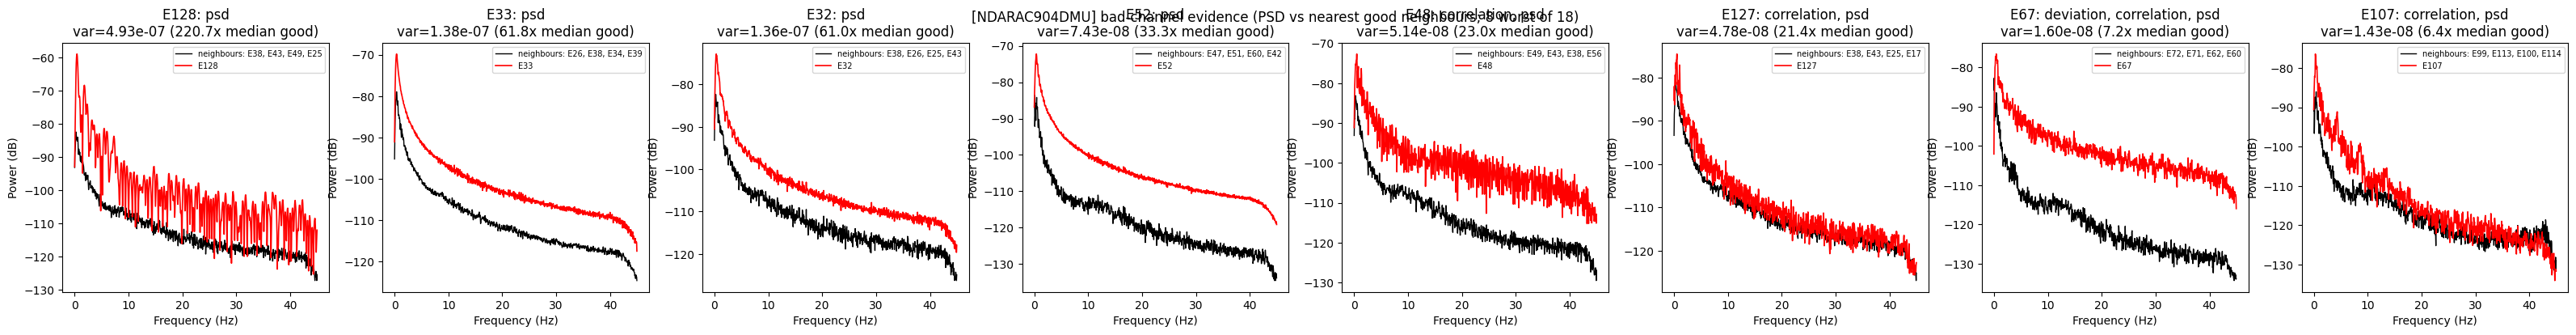

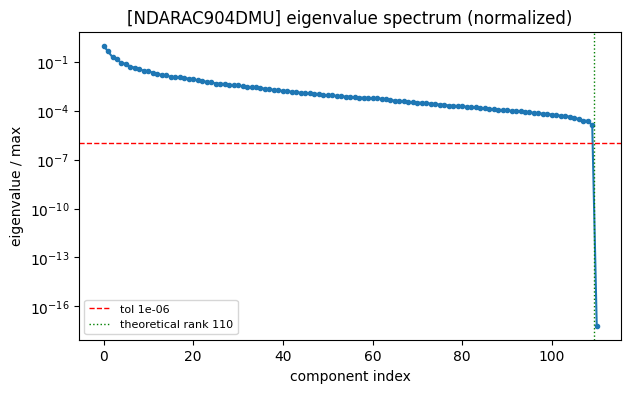

In [119]:
# section 8-10 DRIVER  -  bad channels -> average reference -> effective rank
# Operates on the Stage-2 outputs raw_store (0.1 Hz) and raw_ica_fit (1-45 Hz).
init_subject_provenance(VALIDATION_SUBJECT)
bads, bad_reasons, bad_frac = detect_bad_channels(raw_store)
raw_ica_fit.info["bads"] = list(bads)               # same bads on the ICA-fit copy
assert bad_frac <= MAX_BAD_FRACTION, f"Bad-channel fraction {bad_frac:.2f} exceeds MAX_BAD_FRACTION"

badchan_ev = bad_channel_evidence(raw_store, bads, bad_reasons, VALIDATION_SUBJECT)

# reference-vertex reconstruction check: Cz is flat before, non-flat after average referencing.
_cz_before = float(np.var(raw_store.get_data(picks=[REFERENCE_CHANNEL])[0])) if REFERENCE_CHANNEL in raw_store.ch_names else None
apply_reference(raw_store)
apply_reference(raw_ica_fit)
assert raw_store.info["custom_ref_applied"]
assert raw_ica_fit.info["custom_ref_applied"]
if _cz_before is not None:
    _cz_after = float(np.var(raw_store.get_data(picks=[REFERENCE_CHANNEL])[0]))
    assert _cz_after > _cz_before, "Average reference did not reconstruct the flat Cz vertex."
    print(f"[reference] {REFERENCE_CHANNEL} variance {_cz_before:.2e} -> {_cz_after:.2e} (reconstructed)")
reference_text = emit_reference_comparison()

_zap = int(PROVENANCE["subjects"][VALIDATION_SUBJECT].get("line_noise", {}).get("effective_rank_change", 0))
n_rank, n_theo = estimate_rank(raw_ica_fit, VALIDATION_SUBJECT, n_zapline_removed=_zap)
assert abs(n_rank - n_theo) <= QC_RANK_TOL, f"Empirical rank {n_rank} vs theoretical {n_theo}"

PROVENANCE["subjects"][VALIDATION_SUBJECT]["bad_channels"] = dict(
    channels=list(bads), reasons=bad_reasons, fraction=bad_frac, evidence=badchan_ev)
PROVENANCE["subjects"][VALIDATION_SUBJECT]["reference"] = REFERENCE_METHOD
PROVENANCE["subjects"][VALIDATION_SUBJECT]["rank"] = dict(empirical=n_rank, theoretical=n_theo)
print(f"\nprep OK | bads={bads} | reference={REFERENCE_METHOD} | rank={n_rank}")


[ICA] method=picard(extended=True) n_components=110 n_iter=159 converged=True


c:\Python312\Lib\site-packages\mne_icalabel\iclabel\features.py:66: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  warn(


[ICLabel] labels: IC0:other(0.70), IC1:brain(0.48), IC2:muscle artifact(0.68), IC3:eye blink(0.97), IC4:muscle artifact(0.38), IC5:other(0.61), IC6:brain(0.74), IC7:other(0.66), IC8:other(0.86), IC9:other(0.62), IC10:other(0.49), IC11:eye blink(0.71), IC12:other(0.62), IC13:other(0.86), IC14:other(0.93), IC15:brain(0.51), IC16:brain(0.95), IC17:brain(0.97), IC18:heart beat(0.45), IC19:brain(0.78), IC20:other(0.56), IC21:other(0.97), IC22:brain(0.95), IC23:channel noise(0.99), IC24:other(0.97) ...
[ICLabel] auto-exclude (artifact >= threshold, P(brain)<= 0.2): [3, 23, 31, 42]
[Fp-proxy] eye-like components: [np.int64(2), np.int64(0), np.int64(3), np.int64(4), np.int64(24), np.int64(1), np.int64(8), np.int64(94), np.int64(13)]  (proxies=['E21', 'E14'])
[cross-check] ICLabel-eye AND Fp-proxy (overlap) = [3] (agreement 0.25)
ICLabel / Fp-proxy agreement: 0.25


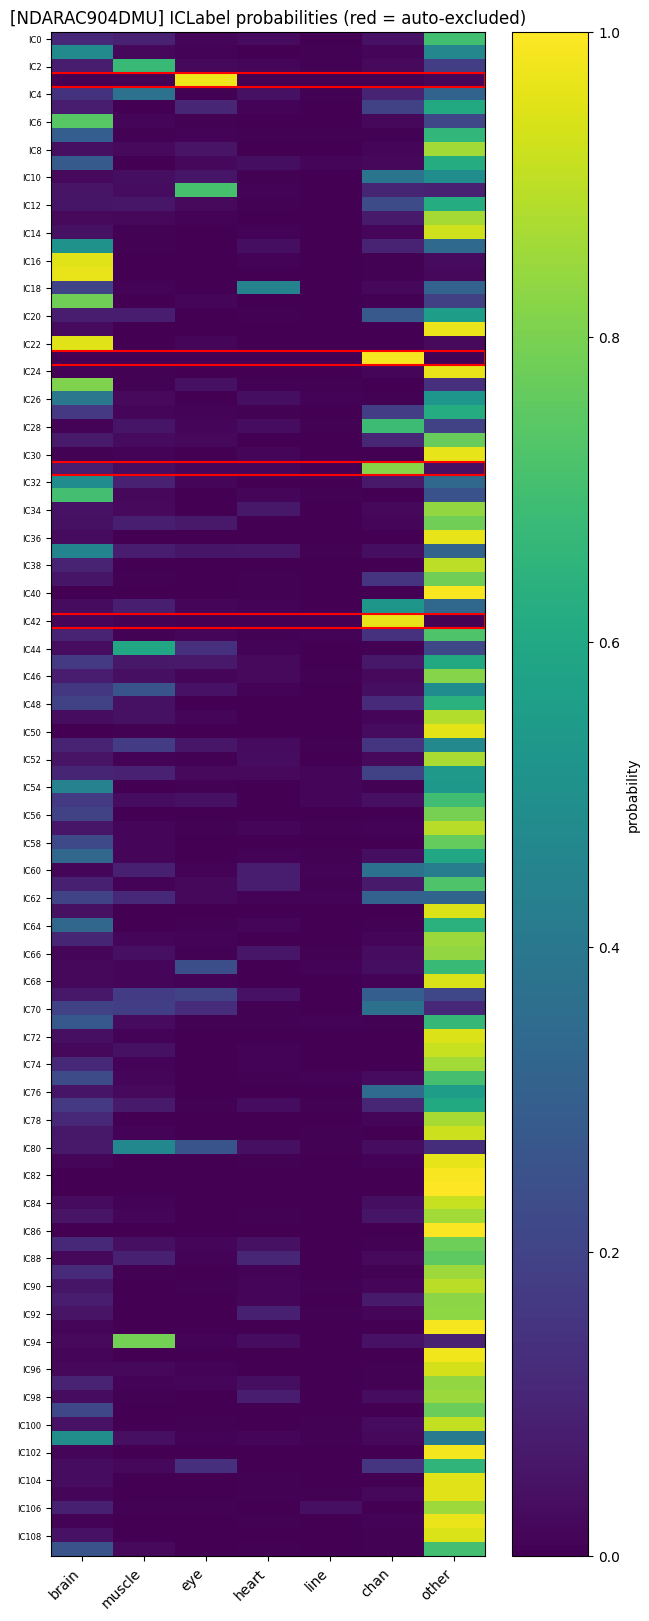

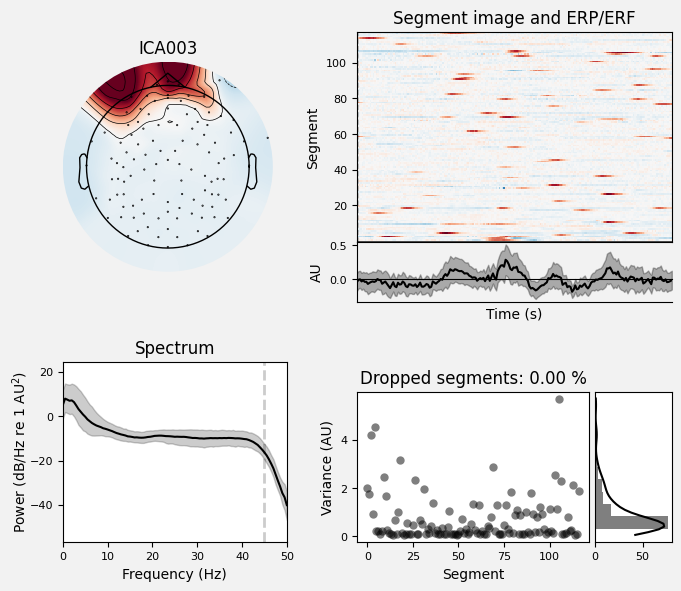

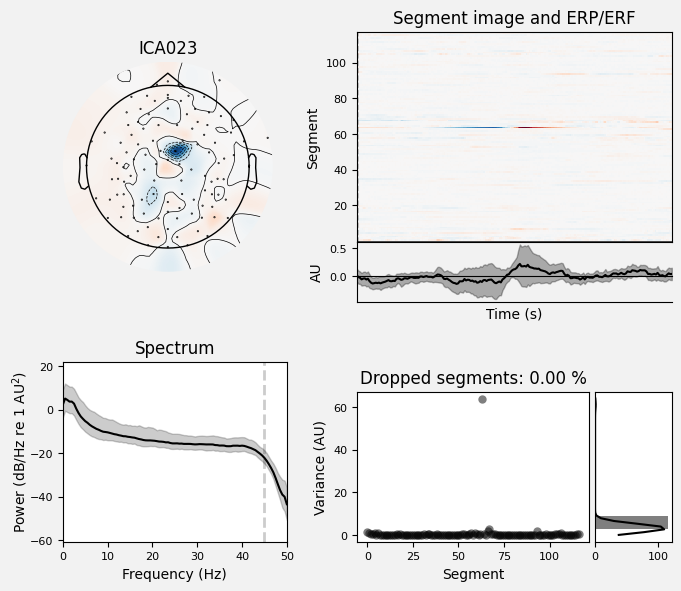

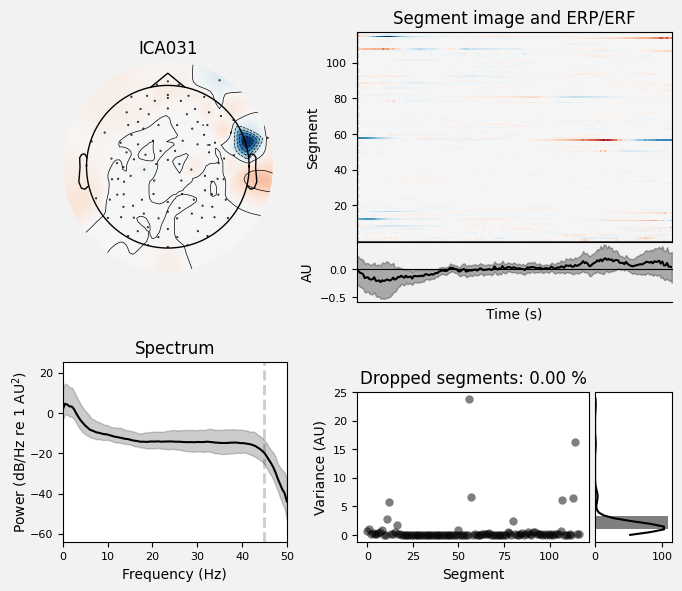

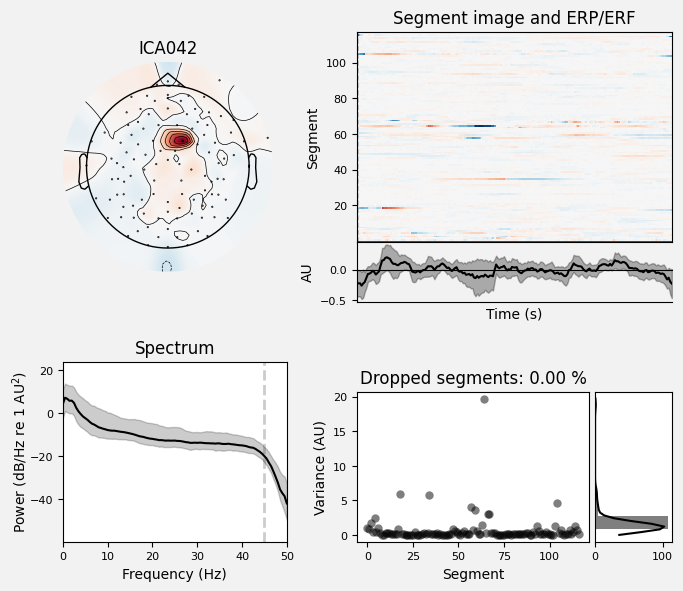

In [120]:
# STEP 3 DRIVER (part 1)  -  fit ICA, label with ICLabel, plot for inspection
ica, ica_converged = fit_ica(raw_ica_fit, n_rank)
assert ica_converged, f"ICA did not converge in {ICA_MAX_ITER} iterations"
assert ica.n_components_ == n_rank

label_info = label_ica(ica, raw_ica_fit)

# Sanity: exactly one ICLabel prediction per ICA component.
assert label_info["proba"].shape[0] == ica.n_components_

# Agreement between ICLabel automatic exclusions and the E22/E9 blink proxy (reported only).
agreement = (len(set(label_info["auto_exclude"]) & set(label_info["eog_idx"]))
             / max(len(label_info["auto_exclude"]), 1))
print(f"ICLabel / Fp-proxy agreement: {agreement:.2f}")

step3_plot_ica(ica, raw_ica_fit, label_info, VALIDATION_SUBJECT)

assert len(label_info["auto_exclude"]) <= (QC_ICA_MAX_REJECT_FRAC * ica.n_components_), \
    "Auto-exclude flags an implausibly large fraction of components."


In [121]:
# MANUAL CONFIRMATION CHECKPOINT (STEP 3)
# Inspect the figures above (ICLabel probabilities, excluded-component properties, Fp-proxy
# overlap), THEN set the final exclusion list. The default is the ICLabel auto-selection; edit it
# here if your visual inspection disagrees. Every removal is logged with its ICLabel class+prob.
ica.exclude = list(label_info["auto_exclude"])     # <-- edit after inspection if needed
_excl_log = [{"ic": int(k), "label": label_info["labels"][k],
              "prob": float(label_info["proba"][k].max())} for k in ica.exclude]
print("Confirmed exclusions:", _excl_log)


Confirmed exclusions: [{'ic': 3, 'label': 'eye blink', 'prob': 0.9749032258987427}, {'ic': 23, 'label': 'channel noise', 'prob': 0.9876298904418945}, {'ic': 31, 'label': 'channel noise', 'prob': 0.8230397701263428}, {'ic': 42, 'label': 'channel noise', 'prob': 0.9676967263221741}]


[apply] excluded=[3, 23, 31, 42]  removed RMS fraction=10.26%  posterior alpha retain=95.1%
[ocular-Fp] IC3: vert=0.42, horiz=-0.06, vertical (weak support)
Updated provenance: derivatives\sub-NDARAC904DMU\eeg\provenance.json

STAGE 3 COMPLETE: bad channels + average reference + rank + ICA/ICLabel applied.


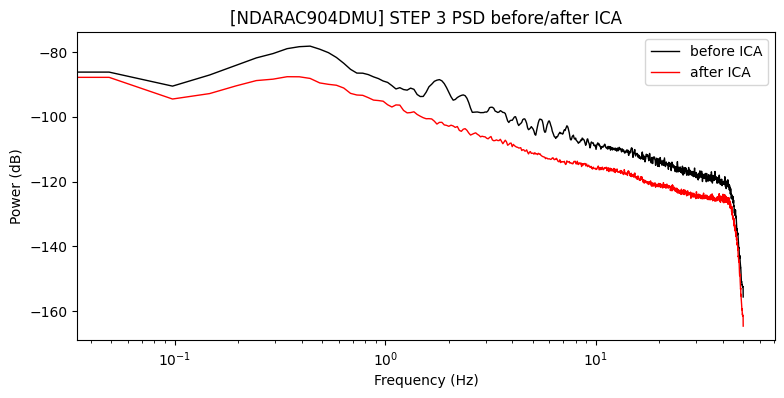

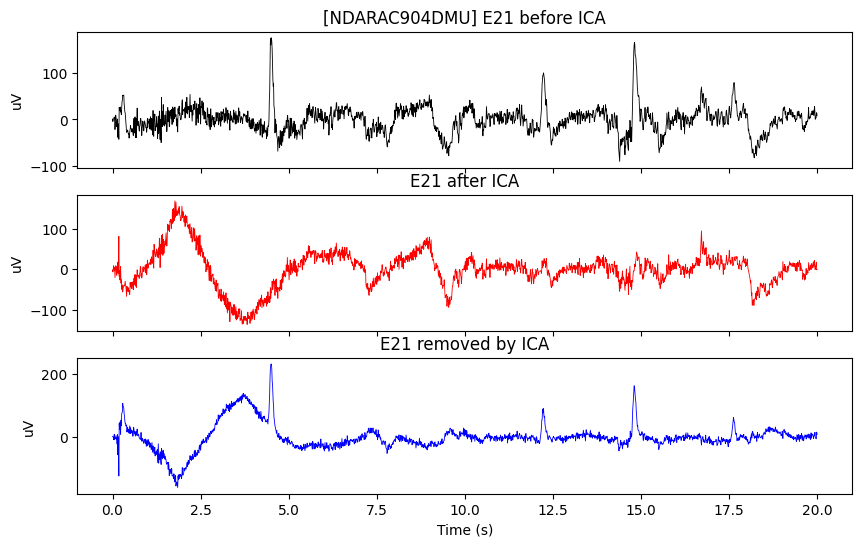

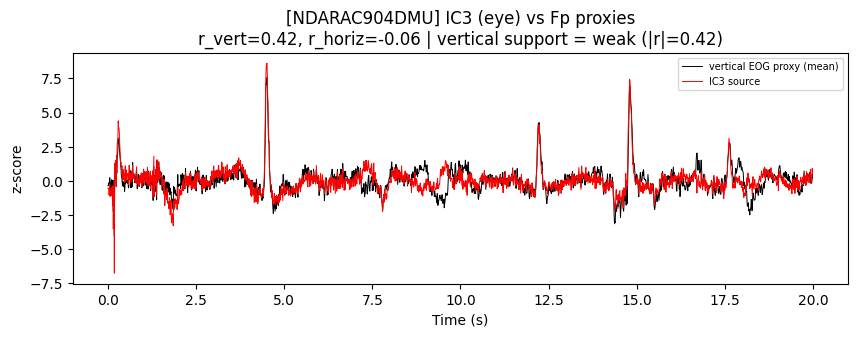

In [122]:
# STEP 3 DRIVER (part 2)  -  apply ICA to the 0.1 Hz stored data + QC
posterior = get_posterior_channels(raw_store)
raw_clean, ica_qc = step3_apply_and_qc(ica, raw_store, posterior, VALIDATION_SUBJECT)
ocular_ev = ocular_fp_evidence(ica, raw_ica_fit, ica.exclude, label_info["labels"], VALIDATION_SUBJECT)

# ICA should not modify bad-channel annotations.
assert raw_clean.info["bads"] == raw_store.info["bads"]
# QC assertions (dynamic / literature-tolerance, not dataset-specific)
assert len(raw_clean.annotations) == len(raw_store.annotations), "Annotations lost during ICA apply."
assert ica_qc["alpha_retain"] >= QC_ALPHA_MIN_RETAIN, \
    f"Posterior alpha dropped to {ica_qc['alpha_retain']*100:.1f}% (< {QC_ALPHA_MIN_RETAIN*100:.0f}%)."

PROVENANCE["subjects"][VALIDATION_SUBJECT]["ica_qc"] = ica_qc
PROVENANCE["subjects"][VALIDATION_SUBJECT]["ica"] = dict(
    method=ICA_METHOD, extended=ICA_EXTENDED, n_components=int(ica.n_components_),
    n_iter=int(ica.n_iter_), converged=bool(ica_converged), excluded=_excl_log,
    n_excluded=len(ica.exclude), fp_proxy_eye=label_info["eog_idx"],
    fp_iclabel_agreement=agreement, ocular_fp_evidence=ocular_ev,
    posterior_channels=posterior, **ica_qc)
prov_path = write_provenance(VALIDATION_SUBJECT)
print("Updated provenance:", prov_path)
print("\nSTAGE 3 COMPLETE: bad channels + average reference + rank + ICA/ICLabel applied.")


## 11 · Stage 4 — Derivative & epochs
Interpolate flagged channels (kept flagged), save the broadband cleaned derivative + ICA + ICLabel table, and cut ready-to-use epochs locked to the left/right visual target.


In [123]:
# Stage 4 (output) configuration -- new-stage parameters, logged in provenance per subject.
ERP_TASK_ROI  = _posterior_roi(4)             # posterior visual ROI, derived from montage geometry
BIDS_TASK     = TASK_LABEL                     # BIDS task label for the export
EXPORT_BIDS   = True                           # skip gracefully if mne_bids is unavailable
AR_MIN_RETAIN = 0.4                            # min epoch fraction kept by AutoReject; relaxed for the pediatric, few-trial CCD data
AR_INTERP_WARN_FRAC = 0.25                     # QC-report flag: channels interpolated in > this fraction of epochs
print("Stage-4 configuration loaded.")


Stage-4 configuration loaded.


In [124]:
# STEP 4 - interpolate, store the non-destructive derivative, build ready-to-use ERP epochs, and
def _lock_events_from_markers(marker_df, sfreq):
    """Build an MNE events array + event_id + metadata for the ERP-lock events directly from the"""
    rows = marker_df[marker_df["in_bounds"] & marker_df["label"].isin(ERP_LOCK_VALUES)].copy()
    rows = rows.sort_values("onset_s").reset_index(drop=True)
    samples = np.round(rows["onset_s"].to_numpy() * sfreq).astype(int)
    codes = rows["label"].map(COND_SIDE).to_numpy().astype(int)
    ev = np.column_stack([samples, np.zeros_like(samples), codes])
    eid = {v: COND_SIDE[v] for v in ERP_LOCK_VALUES}
    meta = pd.DataFrame({"onset_s": rows["onset_s"].to_numpy(),
                         "condition": rows["label"].to_numpy(),
                         "side": rows["label"].str.replace("_target", "", regex=False).to_numpy()})
    return ev, eid, meta

def interpolate_and_store(raw_clean, ica, label_info, subject):
    import csv
    raw_final = raw_clean.copy()
    interpolated = list(raw_final.info["bads"])
    pd.DataFrame({"channel": interpolated, "interpolated": True}).to_csv(
        subject_deriv_dir(subject) / "interpolated_channels.csv", index=False)
    if interpolated:
        raw_final.interpolate_bads(reset_bads=False, verbose=False)
        assert set(raw_final.info["bads"]) == set(interpolated)  # flag retained
    d = subject_deriv_dir(subject)
    raw_final.save(d / f"sub-{subject}_desc-cleaned_raw.fif", overwrite=True, verbose=False)
    ica.save(d / f"sub-{subject}_ica.fif", overwrite=True, verbose=False)

    classes = ["brain", "muscle artifact", "eye blink", "heart beat",
               "line noise", "channel noise", "other"]
    proba = label_info["proba"]
    with open(d / f"sub-{subject}_iclabels.tsv", "w", newline="") as f:
        w = csv.writer(f, delimiter="\t")
        w.writerow(["component", "label", "excluded"] + classes)
        for k in range(proba.shape[0]):
            w.writerow([f"IC{k}", label_info["labels"][k], int(k in ica.exclude)]
                       + [f"{p:.4f}" for p in proba[k]])

    # output verification (new): reload the derivative and confirm shape/sfreq/channels match.
    _chk = mne.io.read_raw_fif(d / f"sub-{subject}_desc-cleaned_raw.fif", verbose=False)
    assert _chk.info["sfreq"] == raw_final.info["sfreq"]
    assert _chk.ch_names == raw_final.ch_names
    assert _chk.n_times == raw_final.n_times

    print(f"[store] interpolated={interpolated if interpolated else 'none'} | "
          f"saved desc-cleaned_raw.fif + ica.fif + iclabels.tsv (reload verified)")
    return raw_final, interpolated

def build_task_epochs(raw_final, marker_df, subject):
    from autoreject import AutoReject
    raw_erp = raw_final.copy().filter(None, LP_FREQ_ERP, verbose=False)
    raw_erp.info["bads"] = []      # use the interpolated channels in the ready-to-use epochs

    ev, eid, meta = _lock_events_from_markers(marker_df, raw_erp.info["sfreq"])
    assert len(ev) == len(meta) and len(ev) > 0, "No in-bounds lock events to epoch."

    epochs = mne.Epochs(raw_erp, ev, event_id=eid, tmin=EPOCH_TMIN, tmax=EPOCH_TMAX,
                        baseline=BASELINE, metadata=meta, preload=True, verbose=False)
    n_before = len(epochs)

    ar = AutoReject(random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=False)
    epochs_ar, reject_log = ar.fit_transform(epochs, return_log=True)
    n_after = len(epochs_ar)
    np.save(subject_deriv_dir(subject) / "step4_autoreject_labels.npy", reject_log.labels)

    d = subject_deriv_dir(subject)
    epochs_ar.save(d / f"sub-{subject}_desc-{TASK_LABEL}_epo.fif", overwrite=True, verbose=False)
    assert len(epochs_ar.metadata) == len(epochs_ar)

    # --- QC 1: AutoReject reject-log matrix ---
    reject_log.plot("horizontal", show=False)
    save_fig(plt.gcf(), "step4_autoreject_log", subject)

    # --- QC 1b: per-channel AutoReject repair statistics ---
    lab = reject_log.labels
    n_ep = lab.shape[0]
    interp_pct = np.nansum(lab == 1, axis=0) / n_ep * 100.0
    badni_pct = np.nansum(lab == 2, axis=0) / n_ep * 100.0
    ch_stats = {epochs.ch_names[i]: dict(interp_pct=float(interp_pct[i]),
                                         bad_not_interp_pct=float(badni_pct[i]))
                for i in range(len(epochs.ch_names))}
    order = np.argsort(interp_pct + badni_pct)[::-1][:40]   # [HBN] show the 40 worst of 129
    figc, axc = plt.subplots(figsize=(12, 4))
    x = np.arange(len(order))
    axc.bar(x, interp_pct[order], color="C0", label="interpolated")
    axc.bar(x, badni_pct[order], bottom=interp_pct[order], color="C3",
            label="bad, NOT interpolated (data retained)")
    axc.axhline(AR_INTERP_WARN_FRAC * 100, color="k", ls="--", lw=1, label=f"{AR_INTERP_WARN_FRAC*100:.0f}% flag")
    axc.set_xticks(x); axc.set_xticklabels([epochs.ch_names[i] for i in order], rotation=90, fontsize=7)
    axc.set(ylabel="% of epochs", title=f"[{subject}] STEP 4 AutoReject per-channel repair (40 worst)")
    axc.legend(fontsize=8)
    save_fig(figc, "step4_autoreject_channel_stats", subject)
    flagged = [epochs.ch_names[i] for i in range(len(epochs.ch_names))
               if interp_pct[i] > AR_INTERP_WARN_FRAC * 100]

    # --- QC 2: trial retention per condition (side) ---
    def _counts(ep):
        return dict(ep.metadata["condition"].value_counts()) if ep.metadata is not None else {}
    c_before = _counts(epochs); c_after = _counts(epochs_ar)
    conds = sorted(c_before)
    fig, ax = plt.subplots(figsize=(7, 4))
    xx = np.arange(len(conds))
    ax.bar(xx - 0.2, [c_before.get(c, 0) for c in conds], 0.4, label="epoched", color="0.7")
    ax.bar(xx + 0.2, [c_after.get(c, 0) for c in conds], 0.4, label="kept (AutoReject)", color="C0")
    ax.set_xticks(xx); ax.set_xticklabels(conds)
    ax.set(ylabel="trials", title=f"[{subject}] STEP 4 trial retention ({n_after}/{n_before} kept)")
    ax.legend(fontsize=8)
    save_fig(fig, "step4_trial_retention", subject)

    # --- QC 3: preliminary ERP sanity (left vs right target, posterior ROI) -- NOT the analysis ---
    rois = [c for c in ERP_TASK_ROI if c in epochs_ar.ch_names]
    sanity_ok = False
    if rois and len(set(epochs_ar.metadata["condition"])) == 2:
        QC_TAG = "QC ONLY -- NOT the statistical ERP result"
        ev_l = epochs_ar['condition == "left_target"'].average()
        ev_r = epochs_ar['condition == "right_target"'].average()
        figs = mne.viz.plot_compare_evokeds(
            {"left_target": ev_l, "right_target": ev_r}, picks=rois, combine="mean",
            invert_y=True, show=False,
            title=f"[{subject}] STEP 4 left vs right target (posterior ROI mean) -- {QC_TAG}")
        save_fig(figs[0] if isinstance(figs, list) else figs, "step4_erp_sanity", subject)
        sanity_ok = True

    print(f"[epochs] kept {n_after}/{n_before} | condition kept={c_after}")
    return epochs_ar, dict(n_before=n_before, n_after=n_after,
                           retention=n_after / max(n_before, 1), cond_before=c_before,
                           cond_after=c_after, rois=rois, erp_sanity_plotted=sanity_ok,
                           ar_channel_stats=ch_stats, ar_flagged=flagged)

def export_bids(raw_final, subject):
    if not EXPORT_BIDS:
        print("[BIDS] export disabled (EXPORT_BIDS=False).")
        return None
    try:
        from mne_bids import BIDSPath, write_raw_bids
    except Exception as e:
        print(f"[BIDS] mne_bids unavailable ({type(e).__name__}); skipping BIDS export.")
        return None
    r = raw_final.copy()
    r.info["line_freq"] = LINE_FREQ
    sub = "".join(ch for ch in subject if ch.isalnum())     # BIDS labels: alphanumeric only
    bids_root = DERIV_ROOT / "bids"
    bp = BIDSPath(subject=sub, task=BIDS_TASK, datatype="eeg", root=bids_root)
    try:
        write_raw_bids(r, bp, format="BrainVision", allow_preload=True, overwrite=True, verbose=False)
    except Exception as e:
        print(f"[BIDS] export failed ({type(e).__name__}: {e}); continuing without BIDS.")
        return None
    print(f"[BIDS] exported -> {bids_root} (sub-{sub}, task-{BIDS_TASK})")
    return str(bids_root)


[store] interpolated=[np.str_('E103'), 'E104', np.str_('E105'), 'E107', 'E122', 'E127', 'E128', 'E32', 'E33', 'E44', 'E48', 'E52', 'E53', 'E55', np.str_('E6'), 'E67', 'E83', np.str_('E86')] | saved desc-cleaned_raw.fif + ica.fif + iclabels.tsv (reload verified)
[epochs] kept 17/24 | condition kept={'right_target': np.int64(10), 'left_target': np.int64(7)}
[BIDS] exported -> derivatives\bids (sub-NDARAC904DMU, task-contrastChangeDetection)
Updated provenance: derivatives\sub-NDARAC904DMU\eeg\provenance.json

STAGE 4 COMPLETE: interpolation + non-destructive derivative + task epochs + BIDS export.


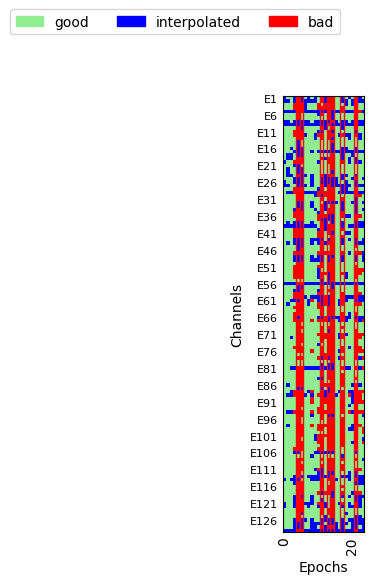

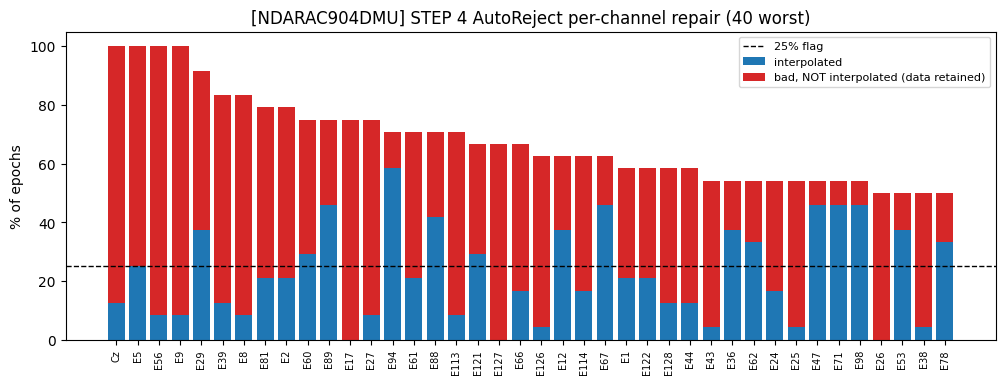

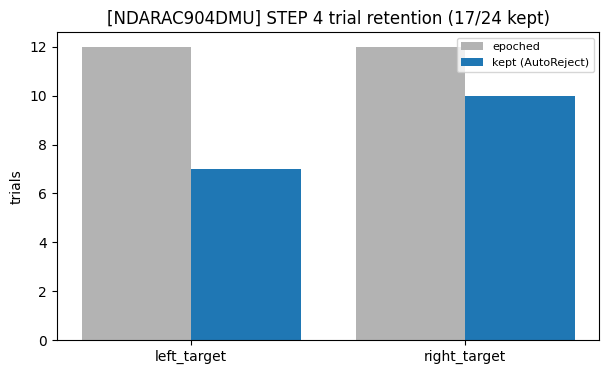

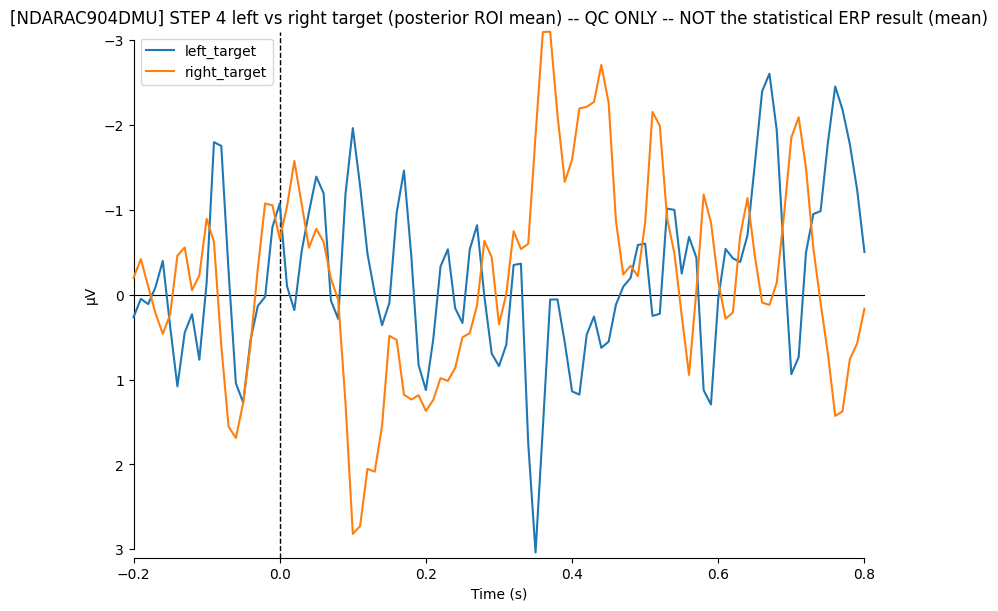

In [125]:
# STEP 4 DRIVER  -  interpolate + store derivative + task epochs + BIDS export
raw_final, interpolated = interpolate_and_store(raw_clean, ica, label_info, VALIDATION_SUBJECT)
assert set(interpolated) == set(bads), "Interpolated set does not match detected bad channels."

epochs_task, epo_qc = build_task_epochs(raw_final, marker_df, VALIDATION_SUBJECT)
assert epo_qc["retention"] >= AR_MIN_RETAIN, \
    f"AutoReject retained only {epo_qc['retention']*100:.0f}% of epochs (< {AR_MIN_RETAIN*100:.0f}%)."

bids_root = export_bids(raw_final, VALIDATION_SUBJECT)

PROVENANCE["subjects"][VALIDATION_SUBJECT]["step4"] = dict(
    interpolated=interpolated, erp_lowpass=LP_FREQ_ERP, epochs=epo_qc,
    ar_channel_stats=epo_qc["ar_channel_stats"], ar_flagged=epo_qc["ar_flagged"],
    bids_root=bids_root, bids_task=BIDS_TASK, task_roi=list(ERP_TASK_ROI),
    ar_min_retain=AR_MIN_RETAIN)
prov_path = write_provenance(VALIDATION_SUBJECT)
print("Updated provenance:", prov_path)
print("\nSTAGE 4 COMPLETE: interpolation + non-destructive derivative + task epochs + BIDS export.")


## 12 · ERP view — target-side contrast + SME + reliability
Derived from the Stage-4 epochs (30 Hz low-pass, baseline-corrected, AutoReject-cleaned): per-condition evokeds, the left-vs-right visual-target contrast over the posterior ROI, the **Standardized Measurement Error** (Luck 2021) on the ROI mean amplitude, and split-half reliability. This is a downstream analysis, kept separate from the frozen preprocessing (and, like the epochs file, QC-oriented rather than the definitive statistical result).


In [126]:
# ERP view: per-condition evokeds, ROI mean-amplitude SME (Luck 2021), split-half reliability, and
# the left/right target contrast. Operates on the AutoReject-cleaned Stage-4 epochs.
ERP_COMPONENT_WIN = (0.10, 0.25)   # s, mean-amplitude measurement window (posterior visual response)

def build_erp(epochs, subject):
    roi = [c for c in ERP_TASK_ROI if c in epochs.ch_names] or list(epochs.ch_names[:4])
    conds = [c for c in ("left_target", "right_target")
             if epochs.metadata is not None and (epochs.metadata["condition"] == c).any()]
    evokeds = {c: epochs[f'condition == "{c}"'].average() for c in conds}

    # ROI single-trial mean amplitude in the window -> SME = SD/sqrt(n) (Luck 2021, analytic SME)
    amps, sme = {}, {}
    for c in conds:
        ep = epochs[f'condition == "{c}"'].copy().pick(roi).crop(*ERP_COMPONENT_WIN)
        a = ep.get_data().mean(axis=(1, 2)) * 1e6   # uV, mean over ROI channels + window
        amps[c] = a
        sme[c] = float(np.std(a, ddof=1) / np.sqrt(len(a))) if len(a) > 1 else float("nan")

    # split-half reliability of the ROI waveform: mean over many random splits, Spearman-Brown
    # corrected. Returns None when there are too few trials for a meaningful estimate (Spearman-Brown
    # is undefined for negative correlations, which are common with a handful of noisy trials).
    def _splithalf(c, n_splits=100, min_trials=8):
        ep = epochs[f'condition == "{c}"'].copy().pick(roi)
        n = len(ep)
        if n < min_trials:
            return None
        rng = np.random.RandomState(RANDOM_STATE)
        rs = []
        for _ in range(n_splits):
            idx = rng.permutation(n)
            h1 = ep[idx[:n // 2]].average().data.mean(0)
            h2 = ep[idx[n // 2:2 * (n // 2)]].average().data.mean(0)
            rs.append(np.corrcoef(h1, h2)[0, 1])
        r = float(np.mean(rs))
        return float(2 * r / (1 + r)) if r > 0 else 0.0   # Spearman-Brown only for positive r
    reliability = {c: _splithalf(c) for c in conds}

    def _fmt(x):
        return f"{x:.2f}" if isinstance(x, (int, float)) else "n/a (too few trials)"

    # figures: ROI compare-evokeds + difference joint plot
    figs = mne.viz.plot_compare_evokeds({c: evokeds[c] for c in conds}, picks=roi, combine="mean",
                                        invert_y=True, show=False,
                                        title=f"[{subject}] ERP: target side (posterior ROI mean)")
    save_fig(figs[0] if isinstance(figs, list) else figs, "view_erp_compare", subject)
    if len(conds) == 2:
        try:
            diff = mne.combine_evoked([evokeds[conds[0]], evokeds[conds[1]]], weights=[1, -1])
            fD = diff.plot_joint(title=f"[{subject}] {conds[0]} - {conds[1]} difference", show=False)
            save_fig(fD[0] if isinstance(fD, list) else fD, "view_erp_difference", subject)
        except Exception as ex:
            print(f"  (difference joint plot skipped: {type(ex).__name__})")

    m = dict(roi=roi, window_s=list(ERP_COMPONENT_WIN),
             n_per_cond={c: int(len(amps[c])) for c in conds},
             mean_amp_uV={c: float(np.mean(amps[c])) for c in conds},
             sme_uV=sme, split_half_reliability=reliability)
    print(f"[ERP] {subject} ROI={roi} win={ERP_COMPONENT_WIN}s | " +
          ", ".join(f"{c}: {m['mean_amp_uV'][c]:+.2f}+/-{sme[c]:.2f} uV (SME)" for c in conds) +
          " | reliability " + ", ".join(f"{c}={_fmt(reliability[c])}" for c in conds))
    return evokeds, m


[ERP] NDARAC904DMU ROI=['E75', 'E70', 'E83', 'E74'] win=(0.1, 0.25)s | left_target: -0.25+/-0.63 uV (SME), right_target: +1.36+/-1.25 uV (SME) | reliability left_target=n/a (too few trials), right_target=0.19


'derivatives\\sub-NDARAC904DMU\\eeg\\provenance.json'

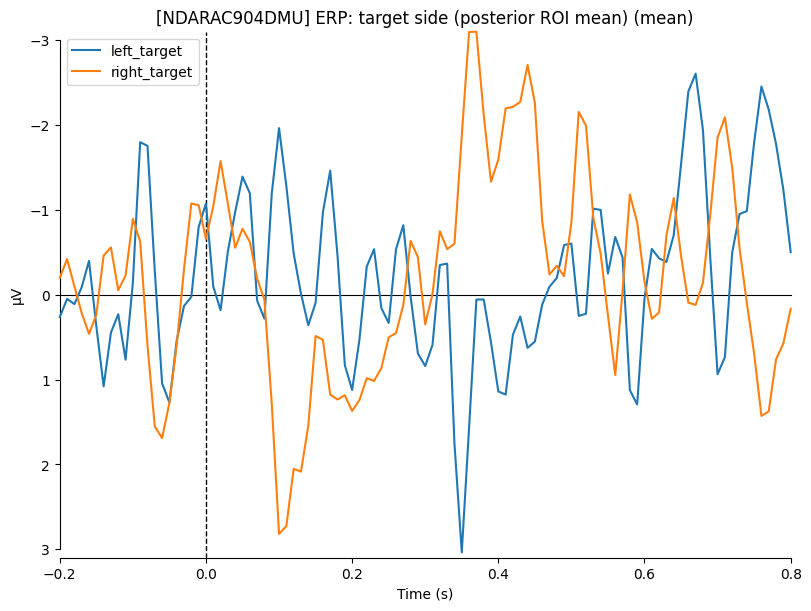

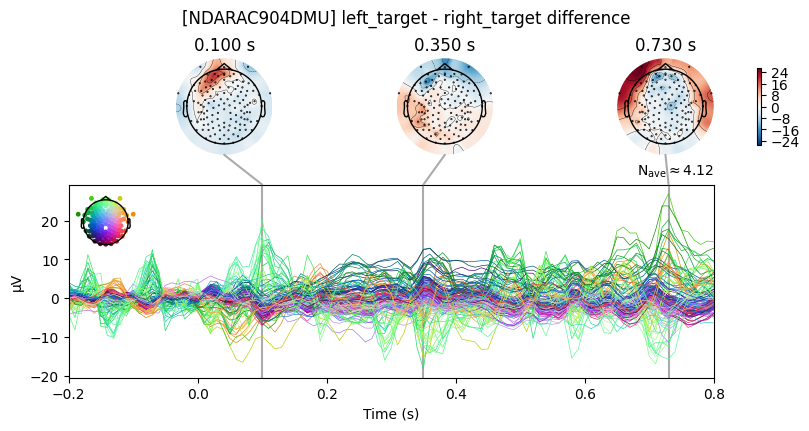

In [127]:
# ERP-view driver (validation subject) -- uses the in-memory Stage-4 epochs.
erp_evokeds, erp_metrics = build_erp(epochs_task, VALIDATION_SUBJECT)
PROVENANCE["subjects"][VALIDATION_SUBJECT]["erp_view"] = erp_metrics
write_provenance(VALIDATION_SUBJECT)


## 13 · Spectral view — PSD, FOOOF, alpha preservation
From the broadband derivative (no ERP low-pass): posterior Welch PSD, a **FOOOF/specparam** aperiodic (1/f offset + exponent) plus periodic (alpha peak) decomposition (Donoghue 2020), and the authoritative **posterior-alpha preservation** check — integrated 8–13 Hz power before vs after ICA. On this eyes-open task alpha is modest; the resting-state recording would show it strongest.


In [128]:
# Spectral view: posterior PSD + FOOOF aperiodic/periodic fit + alpha preservation before/after ICA.
def spectral_view(raw_cleaned, raw_before_ica, posterior_chs, subject):
    nyq = nyquist(raw_cleaned)
    fmax = min(PSD_FMAX, nyq - 1)
    f, d = cached_psd(raw_cleaned, method="welch", fmin=1.0, fmax=fmax,
                      n_fft=QC_BANDPOWER_NFFT, picks=posterior_chs)
    psd_mean = d.mean(0)

    ap = pk = None
    try:
        from fooof import FOOOF
        fm = FOOOF(peak_width_limits=[1, 8], max_n_peaks=6, verbose=False)
        fm.fit(f, psd_mean, [1.0, min(45.0, fmax)])
        ap = dict(offset=float(fm.aperiodic_params_[0]), exponent=float(fm.aperiodic_params_[-1]),
                  r_squared=float(fm.r_squared_), error=float(fm.error_))
        peaks = np.atleast_2d(fm.get_params("peak_params")) if fm.n_peaks_ else np.empty((0, 3))
        al = peaks[(peaks[:, 0] >= ALPHA_BAND[0]) & (peaks[:, 0] <= ALPHA_BAND[1])] if len(peaks) else peaks
        pk = dict(n_peaks=int(len(peaks)),
                  alpha_peak_hz=float(al[np.argmax(al[:, 1]), 0]) if len(al) else None)
        fig, ax = plt.subplots(figsize=(7, 4))
        fm.plot(ax=ax, add_legend=True)
        ax.set_title(f"[{subject}] posterior PSD + FOOOF (exponent={ap['exponent']:.2f}, R2={ap['r_squared']:.2f})")
        save_fig(fig, "view_spectral_fooof", subject)
    except Exception as ex:
        print(f"  (FOOOF fit skipped: {type(ex).__name__}: {ex})")
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.semilogy(f, psd_mean); ax.set(title=f"[{subject}] posterior PSD", xlabel="Hz", ylabel="PSD")
        save_fig(fig, "view_spectral_psd", subject)

    # authoritative alpha-preservation check (integrated posterior 8-13 Hz, before vs after ICA)
    a_before = _bandpower(raw_before_ica, ALPHA_BAND[0], ALPHA_BAND[1], picks=posterior_chs)
    a_after = _bandpower(raw_cleaned, ALPHA_BAND[0], ALPHA_BAND[1], picks=posterior_chs)
    retain = a_after / a_before
    figb, axb = plt.subplots(figsize=(4, 4))
    axb.bar(["before ICA", "after ICA"], [a_before, a_after], color=["k", "r"])
    axb.set(title=f"[{subject}] posterior alpha ({retain*100:.1f}% retained)", ylabel="integrated power")
    save_fig(figb, "view_alpha_preservation", subject)

    m = dict(aperiodic=ap, periodic=pk, alpha_before=a_before, alpha_after=a_after,
             alpha_retention=float(retain))
    print(f"[spectral] {subject} 1/f exponent={ap['exponent'] if ap else 'n/a'} "
          f"alpha_peak={pk['alpha_peak_hz'] if pk else 'n/a'} Hz | alpha retained={retain*100:.1f}%")
    return m


[spectral] NDARAC904DMU 1/f exponent=2.201262276345768 alpha_peak=12.535714216422365 Hz | alpha retained=95.1%


'derivatives\\sub-NDARAC904DMU\\eeg\\provenance.json'

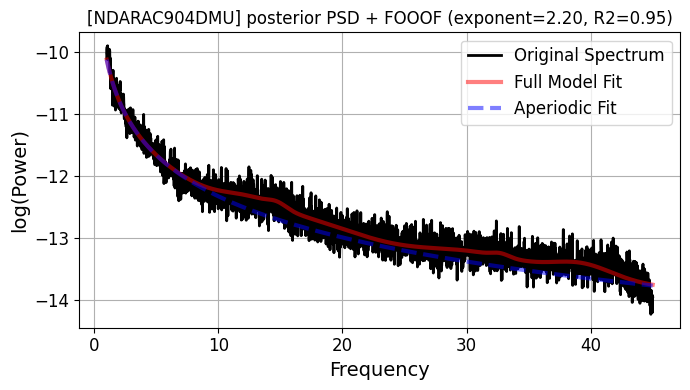

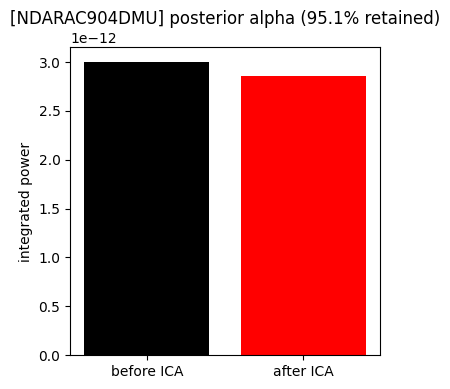

In [129]:
# Spectral-view driver (validation subject): raw_clean = post-ICA, raw_store = pre-ICA (same reference).
spec_metrics = spectral_view(raw_clean, raw_store, posterior, VALIDATION_SUBJECT)
PROVENANCE["subjects"][VALIDATION_SUBJECT]["spectral_view"] = spec_metrics
write_provenance(VALIDATION_SUBJECT)


## 14 · Per-subject QC report
Consolidates every saved QC figure plus a provenance/QC summary table into a single **`mne.Report` HTML** next to the derivatives, and (re)writes `provenance.json`. This is the reproducibility bundle a reviewer opens.


In [130]:
# build_report: assemble an mne.Report HTML from the saved QC figures + a provenance/QC table.
def build_report(subject):
    import glob as _glob
    rep = mne.Report(title=f"HBN preprocessing -- sub-{subject}", verbose=False)
    imgs = sorted(_glob.glob(str(figures_dir(subject) / "*.png")))
    for p in imgs:
        name = os.path.basename(p)[:-4]
        rep.add_image(image=p, title=name, section=name.split("_")[0])
    rec = PROVENANCE["subjects"].get(subject, {})
    rows = [("subject", subject), ("config_hash", PROVENANCE["config_hash"]),
            ("task", f"{TASK_LABEL} {RUN_LABEL}"),
            ("n_bad_channels", len(rec.get("bad_channels", {}).get("channels", []))),
            ("rank", rec.get("rank")),
            ("ica_excluded", rec.get("ica", {}).get("n_excluded")),
            ("alpha_retain", round(rec.get("ica_qc", {}).get("alpha_retain", float("nan")), 3)),
            ("erp_reliability", rec.get("erp_view", {}).get("split_half_reliability")),
            ("fooof_exponent", (rec.get("spectral_view", {}).get("aperiodic") or {}).get("exponent")),
            ("warnings", rec.get("warnings"))]
    html = "<table border=1 cellpadding=5 style='border-collapse:collapse'>" + \
           "".join(f"<tr><td><b>{k}</b></td><td>{v}</td></tr>" for k, v in rows) + "</table>"
    rep.add_html(html, title="QC / provenance summary", section="summary")
    path = subject_deriv_dir(subject) / f"sub-{subject}_report.html"
    rep.save(path, overwrite=True, open_browser=False)
    write_provenance(subject)
    print(f"[report] {subject} -> {path}  ({len(imgs)} figures embedded)")
    return str(path)


In [131]:
# Report driver (validation subject).
report_path = build_report(VALIDATION_SUBJECT)
print("\nANALYSIS VIEWS COMPLETE: ERP + spectral/FOOOF + QC report.")


[report] NDARAC904DMU -> derivatives\sub-NDARAC904DMU\eeg\sub-NDARAC904DMU_report.html  (31 figures embedded)

ANALYSIS VIEWS COMPLETE: ERP + spectral/FOOOF + QC report.


## 15 · Batch
Run the identical pipeline over every discovered subject (ICA removal stays per-subject). Call `run_batch()` to process all subjects.


In [132]:
# run_batch: PREPROCESSING VALIDATION over every subject in SUBJECTS.
def _alpha_snr_db(raw, posterior):
    """Posterior alpha SNR: alpha-peak power over the 15-25 Hz 1/f floor (dB)."""
    f, d = cached_psd(raw, method="welch", fmin=5, fmax=25, picks=posterior, n_fft=QC_BANDPOWER_NFFT)
    P = d.mean(0)
    a = P[(f >= ALPHA_BAND[0]) & (f <= ALPHA_BAND[1])].max()
    floor = np.median(P[(f >= 15) & (f <= 25)])
    return float(10 * np.log10(a / floor))

def validate_preprocessing(S, subject):
    """Cross-cutting before/after QC panel + metrics. before=ingested raw, after=final."""
    raw0, rawf = S["raw"], S["raw_final"]
    posterior = S["posterior"]
    nyq = raw0.info["sfreq"] / 2.0
    hi = min(40.0, nyq - QC_HF_NYQ_MARGIN)   # [HBN] band-match below Nyquist
    # MATCHED referencing: reference BOTH the ingested raw and the final over the SAME good
    # (non-interpolated) channels. Otherwise the raw's common average is contaminated by the very
    # bad channels the pipeline removed, and the raw-vs-final correlation collapses -- a QC artifact,
    # not signal loss (verified: matched posterior preservation is ~0.98 where the naive average-ref
    # metric read ~0.17). Preservation is reported over GOOD channels; interpolated channels are
    # spline estimates and are expected to differ.
    good_ref = [c for c in rawf.ch_names if c not in rawf.info["bads"] and c != REFERENCE_CHANNEL]
    a = raw0.copy().filter(1., hi, verbose=False); a.set_eeg_reference(ref_channels=good_ref, verbose=False)
    b = rawf.copy().filter(1., hi, verbose=False); b.set_eeg_reference(ref_channels=good_ref, verbose=False)
    Da, Db = a.get_data(), b.get_data()
    corr = np.array([np.corrcoef(Da[i], Db[i])[0, 1] for i in range(len(raw0.ch_names))])
    good_idx = [i for i, c in enumerate(rawf.ch_names) if c in good_ref]
    post_idx = [raw0.ch_names.index(c) for c in posterior]
    frontal = [c for c in QC_EOG_PROXY if c in raw0.ch_names]
    fr_idx = [raw0.ch_names.index(c) for c in frontal]
    var0 = np.var(Da, axis=1); varf = np.var(Db, axis=1)   # matched-reference variances

    m = dict(
        preservation_corr_median=float(np.median(corr[good_idx])),
        preservation_corr_posterior=float(np.median(corr[post_idx])),
        preservation_corr_frontal=float(np.median(corr[fr_idx])) if fr_idx else None,
        frontal_var_suppression=float(np.median(varf[fr_idx] / var0[fr_idx])) if fr_idx else None,
        alpha_snr_before_db=_alpha_snr_db(raw0, posterior),
        alpha_snr_after_db=_alpha_snr_db(rawf, posterior),
    )
    m["alpha_snr_gain_db"] = m["alpha_snr_after_db"] - m["alpha_snr_before_db"]

    fig, ax = plt.subplots(2, 3, figsize=(16, 9))
    f0, d0 = cached_psd(raw0, fmax=nyq); ff, df = cached_psd(rawf, fmax=nyq)
    ax[0, 0].plot(f0, 10*np.log10(d0.mean(0)), "k", lw=1, label="raw (ingested)")
    ax[0, 0].plot(ff, 10*np.log10(df.mean(0)), "r", lw=1, label="final cleaned")
    ax[0, 0].set(xscale="log", title="raw vs final PSD", xlabel="Hz", ylabel="dB"); ax[0, 0].legend(fontsize=7)
    ca0 = np.abs(S["raw_preref"].get_data().mean(0)).mean()*1e6
    caf = np.abs(S["raw_store"].get_data().mean(0)).mean()*1e6
    ax[0, 1].bar(["before ref", "after avg-ref"], [ca0, caf], color=["k", "r"])
    ax[0, 1].set(title="common-average |signal| (uV)\n(avg-ref -> ~0)", ylabel="uV")
    ax[0, 2].scatter(var0*1e12, varf*1e12, s=14)
    lim = [0, float(max((var0*1e12).max(), (varf*1e12).max()))]; ax[0, 2].plot(lim, lim, "k--", lw=.8)
    ax[0, 2].set(title="per-channel variance (uV^2)", xlabel="raw", ylabel="final")
    ax[1, 0].bar(range(len(corr)), corr[np.argsort(corr)], color="C0")
    ax[1, 0].axhline(np.median(corr), color="k", ls="--", lw=1)
    ax[1, 0].set(title=f"raw-vs-final corr (1-{hi:.0f}Hz)\nmedian={np.median(corr):.2f} (posterior={m['preservation_corr_posterior']:.2f})",
                 xlabel="channel (sorted)", ylabel="r")
    ax[1, 1].bar(["before", "after"], [m["alpha_snr_before_db"], m["alpha_snr_after_db"]], color=["k", "r"])
    ax[1, 1].set(title=f"posterior alpha SNR (dB)\ngain={m['alpha_snr_gain_db']:+.1f} dB", ylabel="dB")
    if fr_idx:
        ax[1, 2].bar(frontal, (varf[fr_idx]/var0[fr_idx]), color="C3")
        ax[1, 2].axhline(1, color="k", lw=.8)
        ax[1, 2].set(title="frontal variance ratio final/raw\n(<1 = blink/artifact suppressed)", ylabel="ratio")
        ax[1, 2].tick_params(axis="x", rotation=45)
    fig.suptitle(f"[{subject}] preprocessing validation - raw vs final (QC only, no inference)")
    save_fig(fig, "step5_validation_panel", subject)
    print(f"[validate {subject}] preservation r(post)={m['preservation_corr_posterior']:.2f} "
          f"frontal-suppression={m['frontal_var_suppression']} "
          f"alpha-SNR {m['alpha_snr_before_db']:.1f}->{m['alpha_snr_after_db']:.1f} dB")
    return m

def _pipeline_states(subject):
    """Run the FROZEN pipeline for one subject, reusing every stage function; return states."""
    init_subject_provenance(subject)
    raw, events, event_id, marker_df, eeg_ts = load_hbn_recording(subject)
    timing, timing_ok = integrity_qc(eeg_ts, raw.info["sfreq"], subject)
    charac, events_ok = characterize(raw, events, event_id, marker_df, subject)
    step1 = step1_raw_overview(raw, events, event_id, subject)
    raw_ingest = raw.copy()                                   # keep pristine "before"
    raw_line, line_info = run_line_noise(raw, subject)
    raw_store, raw_ica_fit, filt_metrics = apply_filters(raw_line)
    step2_visualize(raw_line, raw_store, raw_ica_fit, subject)
    bads, reasons, frac = detect_bad_channels(raw_store)
    bad_channel_evidence(raw_store, bads, reasons, subject)
    raw_ica_fit.info["bads"] = list(bads)
    raw_preref = raw_store.copy()                             # reference before/after
    apply_reference(raw_store); apply_reference(raw_ica_fit); emit_reference_comparison()
    _zap = int(line_info.get("effective_rank_change", 0))
    n_rank, n_theo = estimate_rank(raw_ica_fit, subject, n_zapline_removed=_zap)
    ica, converged = fit_ica(raw_ica_fit, n_rank)
    label_info = label_ica(ica, raw_ica_fit)
    step3_plot_ica(ica, raw_ica_fit, label_info, subject)
    ica.exclude = list(label_info["auto_exclude"])
    posterior = get_posterior_channels(raw_store)
    ocular_fp_evidence(ica, raw_ica_fit, ica.exclude, label_info["labels"], subject)
    raw_clean, ica_qc = step3_apply_and_qc(ica, raw_store, posterior, subject)
    raw_final, interpolated = interpolate_and_store(raw_clean, ica, label_info, subject)
    return dict(raw=raw_ingest, raw_line=raw_line, raw_preref=raw_preref, raw_store=raw_store,
                raw_ica_fit=raw_ica_fit, ica=ica, label_info=label_info, raw_clean=raw_clean,
                raw_final=raw_final, events=events, event_id=event_id, marker_df=marker_df,
                posterior=posterior, bads=bads, interpolated=interpolated, frac=frac,
                n_rank=n_rank, n_theo=n_theo, converged=converged, ica_qc=ica_qc,
                line_info=line_info, timing=timing, timing_ok=timing_ok, charac=charac,
                events_ok=events_ok, step1=step1)

def run_batch(subjects=SUBJECTS):
    import json as _json, time as _time
    rows = []
    for subject in subjects:
        print("\n" + "#" * 78 + f"\n# SUBJECT: {subject}\n" + "#" * 78)
        t0 = _time.perf_counter()
        S = _pipeline_states(subject)
        vm = validate_preprocessing(S, subject)
        # event-integrity gate for epoching
        if S["events_ok"]:
            epochs, epo_qc = build_task_epochs(S["raw_final"], S["marker_df"], subject)
            epoch_status = "ok"; retention = epo_qc["retention"]; n_kept = epo_qc["n_after"]; n_ep = epo_qc["n_before"]
        else:
            epochs, epo_qc = None, None
            epoch_status = "BLOCKED: lock events missing/single-condition"; retention = None; n_kept = None; n_ep = None
            print(f"  ** EPOCHING BLOCKED for {subject}: {epoch_status} (continuous QC still produced)")
        export_bids(S["raw_final"], subject)
        rt = _time.perf_counter() - t0
        rec = dict(subject=subject, timing_ok=S["timing_ok"], effective_sfreq=S["timing"]["effective_sfreq"],
                   n_stalls=S["timing"]["n_stalls"], events_ok=S["events_ok"],
                   n_lock_events=S["charac"]["n_lock_events"],
                   line_observable=S["line_info"].get("observable", False),
                   n_bad_channels=len(S["bads"]), bad_channels=";".join(S["bads"]),
                   rank_empirical=S["n_rank"], rank_theoretical=S["n_theo"],
                   rank_ok=bool(abs(S["n_rank"] - S["n_theo"]) <= QC_RANK_TOL),
                   rank_deficit=int(S["n_theo"] - S["n_rank"]),
                   ica_converged=S["converged"], ica_n_excluded=len(S["ica"].exclude),
                   ica_removed_frac=S["ica_qc"]["removed_frac"], alpha_retain=S["ica_qc"]["alpha_retain"],
                   epoch_status=epoch_status, epochs_total=n_ep, epochs_kept=n_kept, epoch_retention=retention,
                   runtime_s=round(rt, 1), **{f"val_{k}": v for k, v in vm.items()})
        rows.append(rec)
        with open(subject_deriv_dir(subject) / f"sub-{subject}_validation.json", "w") as f:
            _json.dump(dict(subject=subject, validation_metrics=vm, summary=rec,
                            config_hash=PROVENANCE["config_hash"]), f, indent=2, default=str)
        write_provenance(subject)
        plt.close("all")   # free the subject's figures (already saved to disk)
        print(f"[{subject}] done in {rt:.0f}s | epochs={epoch_status}")
    df = pd.DataFrame(rows)
    df.to_csv(DERIV_ROOT / "preprocessing_summary.csv", index=False)
    print("\n" + "=" * 78 + "\nCROSS-SUBJECT PREPROCESSING VALIDATION SUMMARY\n" + "=" * 78)
    cols = ["subject", "timing_ok", "events_ok", "n_bad_channels", "rank_ok", "rank_deficit",
            "ica_n_excluded", "ica_removed_frac", "alpha_retain",
            "val_preservation_corr_posterior", "val_frontal_var_suppression", "epoch_retention"]
    print(df[cols].to_string(index=False))
    # headline audit lines (trustworthy, matched-reference metrics)
    print(f"\nSIGNAL PRESERVED  : posterior preservation r  median={df['val_preservation_corr_posterior'].median():.3f} "
          f"min={df['val_preservation_corr_posterior'].min():.3f} | alpha retained median={df['alpha_retain'].median():.3f}")
    print(f"CLEANED MINIMALLY : ICA removed RMS median={df['ica_removed_frac'].median()*100:.1f}% "
          f"| frontal variance -> median={df['val_frontal_var_suppression'].median():.2f}x (artifact suppressed)")
    _rd = df[~df["rank_ok"]]
    if len(_rd):
        print(f"RANK-DEFICIENT    : {len(_rd)} subject(s) have empirical rank < theoretical by >{QC_RANK_TOL} "
              f"(likely channels already interpolated upstream by HBN QC -> ICA was correctly rank-limited): "
              f"{_rd['subject'].tolist()}")
    print(f"\nSummary written -> {DERIV_ROOT / 'preprocessing_summary.csv'}")
    return df

# To run the full 20-subject batch, execute:  batch_summary = run_batch()
print("Batch functions loaded. Call run_batch() to process every discovered subject.")


Batch functions loaded. Call run_batch() to process every discovered subject.


before/after ICA browser figure saved.


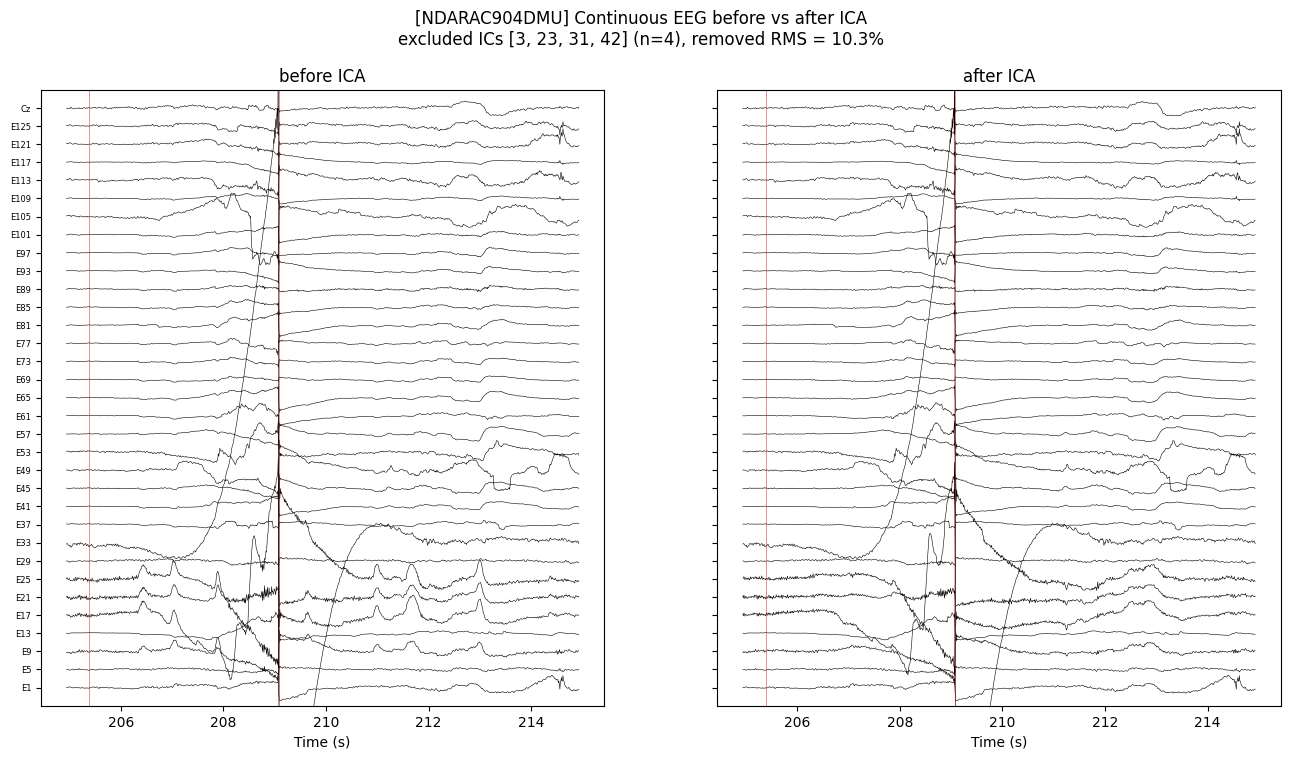

In [133]:
# Continuous EEG before vs after ICA, auto-centred on the window of maximum frontal (ocular)
# removal so the cleaning is immediately visible. Both panels share scaling and time window.
_proxy = [c for c in QC_EOG_PROXY if c in raw_store.ch_names]        # frontal blink proxy (config)
_removed_front = np.abs((raw_store.get_data(picks=_proxy)
                         - raw_clean.get_data(picks=_proxy)).mean(axis=0))
_sf = raw_store.info["sfreq"]
_wlen = int(10.0 * _sf)                                              # 10 s display page
_cs = np.cumsum(_removed_front)                                     # window of max frontal removal
_start = int(np.argmax(_cs[_wlen:] - _cs[:-_wlen]))                 # data-driven start (no hardcoded time)
_t0 = _start / _sf

_removed = raw_store.get_data() - raw_clean.get_data()
_rms_frac = float(np.sqrt(np.mean(_removed ** 2)) / np.sqrt(np.mean(raw_store.get_data() ** 2)))

# [HBN] show a legible subset of the 129 channels (every ~4th) for the browser overlay.
_chs = raw_store.ch_names[::4]
_pick_idx = [raw_store.ch_names.index(c) for c in _chs]
_before = raw_store.get_data(picks=_pick_idx, start=_start, stop=_start + _wlen) * 1e6
_after = raw_clean.get_data(picks=_pick_idx, start=_start, stop=_start + _wlen) * 1e6
_step = 6.0 * float(np.median(np.std(_before, axis=1)))             # channel offset (uV), from data
_t = _t0 + np.arange(_wlen) / _sf

def _browser(ax, data, title):
    for i in range(len(_chs)):
        ax.plot(_t, data[i] + i * _step, "k", lw=0.4)
    for a in raw_store.annotations:
        if _t0 <= a["onset"] <= _t0 + _wlen / _sf:
            ax.axvline(a["onset"], color="tab:red", lw=0.6, alpha=0.6)
    ax.set_yticks(np.arange(len(_chs)) * _step); ax.set_yticklabels(_chs, fontsize=6)
    ax.set_ylim(-_step, len(_chs) * _step); ax.set(title=title, xlabel="Time (s)")

fig, ax = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
_browser(ax[0], _before, "before ICA")
_browser(ax[1], _after, "after ICA")
fig.suptitle(f"[{VALIDATION_SUBJECT}] Continuous EEG before vs after ICA\n"
             f"excluded ICs {list(map(int, ica.exclude))} (n={len(ica.exclude)}), "
             f"removed RMS = {_rms_frac*100:.1f}%")
save_fig(fig, "step3_before_after_ica_browser", VALIDATION_SUBJECT)
print("before/after ICA browser figure saved.")
